# Transformers desde (casi) cero

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion3/1-transformers-from-scratch.ipynb)

En este notebook implementaremos un clasificador de sentimientos en ingles utilizando transformers. Implementaremos parte de la arquitectura del modelo pieza por pieza para ver como funciona por dentro. Sin embargo, utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

#### Referencias
- Dataset: sentimentdataset.csv

# Universidad Icesi

## Maestria en IA Aplicada

Catedra: **Procesamiento de Lenguaje Natural**

Grupo: **Golf**
Realizado por:
- **Arlex Pino**
- **Alfredo Aponte**


In [42]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

working_set = pkg_resources.working_set
installed_packages = [package.key for package in (working_set if working_set is not None else [])]
IN_COLAB = 'google-colab' in installed_packages

### Cargando el dataset
Este es un dataset pequeño de expresiones de sentimientos y su evaluacion.

In [43]:
import pandas as pd
import warnings
import os
import re
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

# Resuelve la ruta del CSV relativa al notebook, independientemente del cwd del kernel.
_nb_file = globals().get('__vsc_ipynb_file__', None)
_nb_dir = os.path.dirname(os.path.abspath(_nb_file)) if _nb_file else os.getcwd()
dataset_file = os.path.join(_nb_dir, 'sentimentdataset.csv')

print("[Inicio] Preparando carga y limpieza del dataset...")
print(f"[Info] Buscando dataset en: {dataset_file}")

if not os.path.exists(dataset_file):
    print(f"[Error] No se encontró el archivo '{dataset_file}'.")
    df_raw = pd.DataFrame(columns=['Text', 'Sentiment'])
    dataset = []
else:
    print(f"[1/5] Cargando dataset...")
    df_raw = pd.read_csv(dataset_file)
    df_raw = df_raw[['Text', 'Sentiment']].copy()
    print(f"Registros iniciales: {len(df_raw)}")

    df_raw['Text'] = df_raw['Text'].fillna('').astype(str).str.strip()
    df_raw['Sentiment'] = df_raw['Sentiment'].fillna('').astype(str).str.strip()
    print("[2/5] Limpieza básica aplicada en columnas Text y Sentiment.")

    def normalize_sentiment_label(label: str) -> str:
        label = str(label).strip().lower()
        label = re.sub(r"[^a-z\s\-]", "", label)
        label = label.replace('-', ' ')
        label = re.sub(r"\s+", " ", label).strip()

        alias_map = {
            'joy': {'joy', 'happy', 'happiness', 'elation', 'euphoria', 'enthusiasm', 'amusement', 'overjoyed', 'playfuljoy', 'festivejoy', 'zest', 'celebration', 'contentment', 'serenity', 'positivity'},
            'sadness': {'sad', 'sadness', 'grief', 'despair', 'melancholy', 'heartbreak', 'sorrow', 'loss', 'loneliness', 'disappointment', 'devastated', 'desolation', 'heartache', 'ruins', 'darkness', 'exhaustion', 'lostlove', 'solitude'},
            'anger': {'anger', 'hate', 'frustration', 'frustrated', 'bitterness', 'bitter', 'resentment', 'betrayal', 'disgust', 'regret'},
            'fear': {'fear', 'fearful', 'anxiety', 'apprehensive', 'intimidation', 'helplessness', 'pressure', 'suffering', 'emotionalstorm'},
            'love': {'love', 'affection', 'adoration', 'gratitude', 'grateful', 'appreciation', 'compassion', 'compassionate', 'empathetic', 'kindness', 'friendship', 'romance', 'heartwarming', 'touched', 'connection'},
            'surprise': {'surprise', 'awe', 'amazement', 'wonder', 'wonderment', 'enchantment', 'captivation', 'marvel', 'thrill'}
        }

        for canonical_label, aliases in alias_map.items():
            if label in aliases:
                return canonical_label
        return label

    print("[3/5] Normalizando etiquetas de sentimiento...")
    df_raw['Sentiment_norm'] = df_raw['Sentiment'].apply(normalize_sentiment_label)
    df_raw = df_raw[(df_raw['Text'] != '') & (df_raw['Sentiment_norm'] != '')].copy()
    normalized_counts = df_raw['Sentiment_norm'].value_counts()
    print(f"Etiquetas normalizadas detectadas: {normalized_counts.shape[0]}")

    print("[4/5] Agrupando clases raras en 'other'...")
    min_samples_per_class = 10
    valid_classes = normalized_counts[normalized_counts >= min_samples_per_class].index
    df_raw['Sentiment'] = df_raw['Sentiment_norm'].where(
        df_raw['Sentiment_norm'].isin(valid_classes), 'other'
    )

    final_counts = df_raw['Sentiment'].value_counts()
    dataset = df_raw[['Text', 'Sentiment']].to_dict('records')

    print("[5/5] Dataset listo para modelado.")
    print(f"Total de registros finales: {len(dataset)}")
    print(f"Clases: {final_counts.shape[0]}")
    print(final_counts)

df_raw[['Text', 'Sentiment']].head()


[Inicio] Preparando carga y limpieza del dataset...
[Info] Buscando dataset en: c:\Users\apont\OneDrive - Universidad Icesi\Maestria en IA\Semestre III\1. Procesamiento de Lenguaje Natural\icesi-nlp\Entregables\Entregable\Sesion 3\sentimentdataset.csv
[1/5] Cargando dataset...
Registros iniciales: 732
[2/5] Limpieza básica aplicada en columnas Text y Sentiment.
[3/5] Normalizando etiquetas de sentimiento...
Etiquetas normalizadas detectadas: 121
[4/5] Agrupando clases raras en 'other'...
[5/5] Dataset listo para modelado.
Total de registros finales: 732
Clases: 12
Sentiment
other         269
joy           128
sadness        68
love           47
anger          46
positive       45
excitement     37
surprise       31
neutral        18
fear           16
curiosity      16
nostalgia      11
Name: count, dtype: int64


,Text,Sentiment
0,Enjoying a beautiful day at the park!,positive
1,Traffic was terrible this morning.,other
2,Just finished an amazing workout! 💪,positive
3,Excited about the upcoming weekend getaway!,positive
4,Trying out a new recipe for dinner tonight.,neutral


,n,avg_chars,avg_words
Sentiment,,,
other,269,88.22,13.81
joy,128,89.45,13.66
sadness,68,81.34,13.32
love,47,89.70,13.98
anger,46,79.83,12.15
positive,45,40.13,6.58
excitement,37,92.35,14.49
surprise,31,84.10,13.71
neutral,18,84.72,12.33


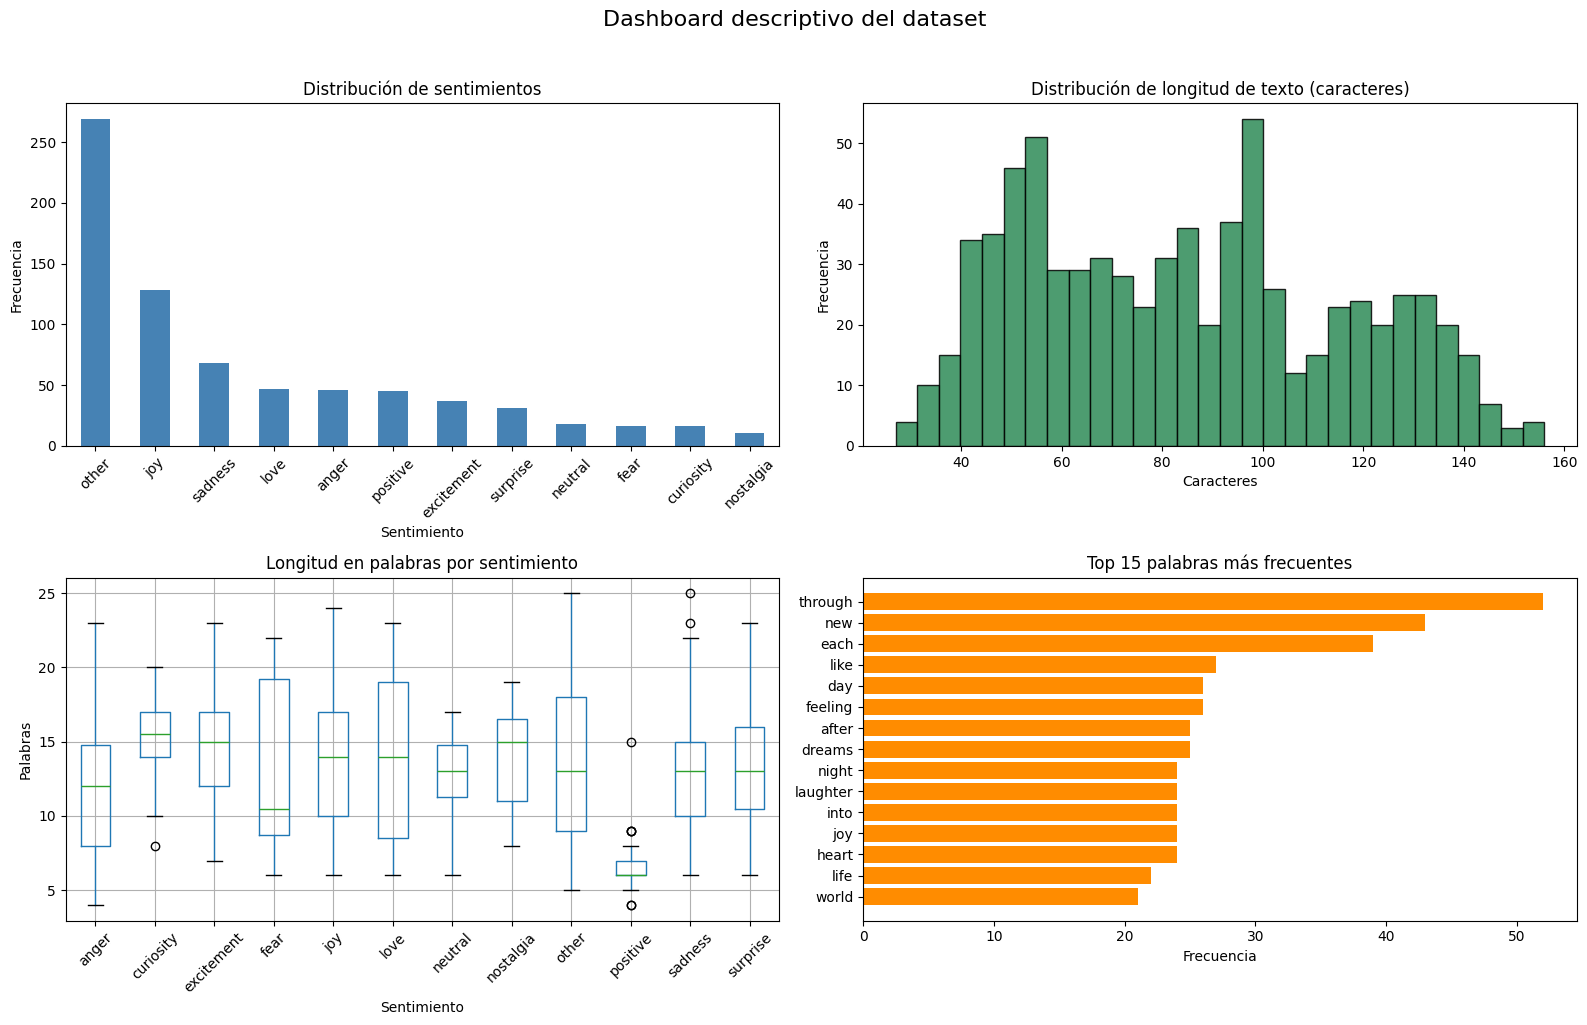

In [44]:
from collections import Counter

# Dashboard descriptivo del dataset
if len(dataset) == 0:
    print("El dataset está vacío.")
else:
    df_dash = df_raw[['Text', 'Sentiment']].copy() if 'df_raw' in globals() else pd.DataFrame(dataset)
    df_dash['char_len'] = df_dash['Text'].astype(str).str.len()
    df_dash['word_len'] = df_dash['Text'].astype(str).str.split().str.len()

    sentiment_counts = final_counts.copy() if 'final_counts' in globals() else df_dash['Sentiment'].value_counts()



    # Resumen por clase
    resumen_por_clase = (
        df_dash.groupby('Sentiment')
        .agg(
            n=('Text', 'size'),
            avg_chars=('char_len', 'mean'),
            avg_words=('word_len', 'mean')
        )
        .sort_values('n', ascending=False)
    )
    display(resumen_por_clase.round(2))

    # Top palabras (limpieza simple)
    stopwords = {
        'the','a','an','and','or','to','of','in','on','at','for','with','is','it','this','that',
        'i','you','we','they','he','she','my','our','your','me','was','are','be','am','just'
    }
    all_tokens = re.findall(r"[a-zA-Z']+", " ".join(df_dash['Text'].astype(str).str.lower().tolist()))
    all_tokens = [t for t in all_tokens if t not in stopwords and len(t) > 2]
    top_words = Counter(all_tokens).most_common(15)

    # Dashboard (2x2)
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # 1) Distribución de clases
    sentiment_counts.sort_values(ascending=False).plot(kind='bar', ax=axes[0, 0], color='steelblue')
    axes[0, 0].set_title('Distribución de sentimientos')
    axes[0, 0].set_xlabel('Sentimiento')
    axes[0, 0].set_ylabel('Frecuencia')
    axes[0, 0].tick_params(axis='x', rotation=45)

    # 2) Longitud de texto (caracteres)
    axes[0, 1].hist(df_dash['char_len'], bins=30, color='seagreen', alpha=0.85, edgecolor='black')
    axes[0, 1].set_title('Distribución de longitud de texto (caracteres)')
    axes[0, 1].set_xlabel('Caracteres')
    axes[0, 1].set_ylabel('Frecuencia')

    # 3) Longitud por clase (palabras)
    df_dash.boxplot(column='word_len', by='Sentiment', ax=axes[1, 0], rot=45)
    axes[1, 0].set_title('Longitud en palabras por sentimiento')
    axes[1, 0].set_xlabel('Sentimiento')
    axes[1, 0].set_ylabel('Palabras')

    # 4) Palabras más frecuentes
    if top_words:
        words, freqs = zip(*top_words)
        axes[1, 1].barh(words, freqs, color='darkorange')
        axes[1, 1].set_title('Top 15 palabras más frecuentes')
        axes[1, 1].set_xlabel('Frecuencia')
        axes[1, 1].invert_yaxis()
    else:
        axes[1, 1].text(0.5, 0.5, 'Sin tokens disponibles', ha='center', va='center')
        axes[1, 1].set_axis_off()

    plt.suptitle('Dashboard descriptivo del dataset', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

### Análisis descriptivo del dataset

El análisis exploratorio permite identificar varias características relevantes del conjunto de datos:

- **Distribución de sentimientos:** El dataset presenta desbalance entre las clases, donde la categoría *other* concentra la mayor cantidad de ejemplos, mientras que emociones como *fear*, *curiosity* y *nostalgia* aparecen con menor frecuencia. Esto puede influir en el desempeño del modelo durante el entrenamiento.

- **Longitud de los textos:** La mayoría de los textos tienen entre **50 y 120 caracteres**, lo que indica que el dataset está compuesto principalmente por frases cortas o comentarios breves.

- **Longitud de texto por emoción:** Se observan pequeñas diferencias en la cantidad de palabras utilizadas según el sentimiento. Algunas emociones tienden a expresarse con frases ligeramente más largas, lo que sugiere variaciones en la forma en que se describen los estados emocionales.

- **Palabras más frecuentes:** Las palabras más comunes incluyen términos asociados a experiencias personales y emociones, como *feeling*, *joy*, *heart* y *dreams*, lo que confirma que el dataset contiene contenido emocional relevante para la tarea de clasificación.

A partir del gráfico de bigotes se observa que la mayoría de los sentimientos presentan medianas similares, generalmente entre **10 y 15 palabras**, lo que sugiere que las frases tienen una longitud relativamente homogénea en el dataset, pero hay algunas emociones muestran mayor dispersión en la longitud del texto, lo que indica que ciertos sentimientos pueden expresarse con frases más extensas o más variables. Los outliers representan casos particulares donde los textos son significativamente más largos o más cortos que el resto.

En general, el gráfico sugiere que **la longitud del texto no varía drásticamente entre emociones**, aunque existen ligeras diferencias en la variabilidad de algunas categorías.

Observemos uno de sus registros...

In [45]:
dataset[0]

{'Text': 'Enjoying a beautiful day at the park!', 'Sentiment': 'positive'}

In [46]:
text_lengths = [len(record['Text']) for record in dataset]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 27
Texto más largo: 156
Longitud promedio: 84.42622950819673


Estos valores son la cantidad de *caracteres* que tiene cada secuencia. Una decisión ingenua pero útil en este momento podría ser ajustar la longitud de las secuencias que vamos a usar para el entrenamiento a unos 2000 tokens; esto suele ser suficiente para capturar una porción significativa de los textos de este dataset.

## Definiendo el Tokenizer

En esta sección entrenamos (o cargamos) un tokenizador basado en GPT-2 adaptado al corpus.

**Objetivo de la celda siguiente:**
- Reutilizar un tokenizador ya guardado para evitar reentrenar innecesariamente.
- Entrenar uno nuevo solo si no existe en disco.
- Definir un `pad_token` válido para que los lotes tengan longitud uniforme.

**Entradas esperadas:**
- `dataset`: lista de registros con llaves `Text` y `Sentiment`.

**Salida principal:**
- `sentimental_tokenizer`: tokenizador listo para preprocesar texto en la tarea de clasificación.

In [47]:
import subprocess
import sys
from tqdm.auto import tqdm
from transformers import AutoTokenizer

import importlib.util

required_packages = {
    "tqdm": "tqdm",
    "transformers": "transformers",
}

for module_name, package_name in required_packages.items():
    if importlib.util.find_spec(module_name) is None:
        print(f"Instalando '{package_name}'...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
    else:
        print(f"'{package_name}' ya está instalado.")


print("Librerías listas para usar.")

'tqdm' ya está instalado.
'transformers' ya está instalado.
Librerías listas para usar.


In [48]:
import os
import shutil
from tqdm.auto import tqdm
from transformers import AutoTokenizer

# Esta celda deja listo el tokenizador del proyecto.
# Flujo:
# 1) Si ya existe un tokenizador entrenado en disco, se reutiliza.
# 2) Si no existe, se entrena uno nuevo a partir del corpus del dataset.
# 3) Se garantiza la presencia de un pad_token para padding uniforme.

# Si la carga del tokenizador guardado falla (archivo corrupto/incompatible),
# se reentrena automáticamente y se vuelve a guardar.


# Usa el mismo directorio base que la celda de carga de datos.
_nb_file = globals().get('__vsc_ipynb_file__', None)
_nb_dir = os.path.dirname(os.path.abspath(_nb_file)) if _nb_file else os.getcwd()
TOKENIZER_SAVE_PATH = os.path.join(_nb_dir, "sentimental_tokenizer")

def bytes_to_unicode():
    """Construye el alfabeto base byte-level usado por GPT-2.

    GPT-2 tokeniza a nivel de bytes y luego mapea esos bytes a caracteres
    unicode seguros para poder entrenar BPE sin perder información.
    Esta función replica ese mapeo para inicializar el vocabulario base.
    """
    bs = (
        list(range(ord("!"), ord("~") + 1))
        + list(range(ord("¡"), ord("¬") + 1))
        + list(range(ord("®"), ord("ÿ") + 1))
    )
    cs = bs[:]
    n = 0
    for b in range(2**8):
        if b not in bs:
            bs.append(b)
            cs.append(2**8 + n)
            n += 1
    cs = [chr(n) for n in cs]
    return dict(zip(bs, cs))

def train_and_save_tokenizer(dataset, save_path):
    """Entrena un tokenizador nuevo desde GPT-2 y lo guarda en disco."""
    if not dataset:
        raise RuntimeError(
            "El dataset está vacío. Verifica que 'sentimentdataset.csv' exista y "
            "vuelve a ejecutar la celda de carga de datos."
        )

    length = min(10000, len(dataset))
    tokenizer = AutoTokenizer.from_pretrained("gpt2")

    byte_to_unicode_map = bytes_to_unicode()
    unicode_to_byte_map = dict((v, k) for k, v in byte_to_unicode_map.items())
    base_vocab = list(unicode_to_byte_map.keys())

    def batch_iterator(batch_size: int = 10):
        """Entrega lotes de textos para entrenar el tokenizador por iteración.

        Args:
            batch_size: cantidad de registros procesados por lote.

        Yields:
            Lista de textos del dataset en cada paso.
        """
        for start in tqdm(range(0, length, batch_size)):
            end = min(start + batch_size, length)
            batch = dataset[start:end]
            if batch:
                yield [record["Text"] for record in batch]

    print("[Tokenizer] Entrenando tokenizador...")
    sentimental_tokenizer = tokenizer.train_new_from_iterator(
        batch_iterator(), vocab_size=50000, initial_alphabet=base_vocab
    )
    sentimental_tokenizer.pad_token = sentimental_tokenizer.eos_token
    sentimental_tokenizer.save_pretrained(save_path)
    print(f"[Tokenizer] Guardado en '{save_path}'.")
    return sentimental_tokenizer

if os.path.isdir(TOKENIZER_SAVE_PATH):
    print(f"[Tokenizer] Cargando tokenizador guardado desde '{TOKENIZER_SAVE_PATH}'...")
    try:
        sentimental_tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_SAVE_PATH)
        print("[Tokenizer] Tokenizador cargado correctamente.")
    except Exception as exc:
        print(f"[Tokenizer][Aviso] Falló la carga del tokenizador guardado: {exc}")
        broken_path = f"{TOKENIZER_SAVE_PATH}_corrupto"
        if os.path.isdir(broken_path):
            shutil.rmtree(broken_path)
        os.replace(TOKENIZER_SAVE_PATH, broken_path)
        print(f"[Tokenizer][Aviso] Se movió la carpeta dañada a: '{broken_path}'")
        sentimental_tokenizer = train_and_save_tokenizer(dataset, TOKENIZER_SAVE_PATH)
else:
    sentimental_tokenizer = train_and_save_tokenizer(dataset, TOKENIZER_SAVE_PATH)

# Aseguramos que el tokenizador siempre tenga token de padding
# para usar truncation/padding en batches de entrenamiento.
if sentimental_tokenizer.pad_token is None:
    sentimental_tokenizer.pad_token = sentimental_tokenizer.eos_token

print(f"[Tokenizer] Listo. Vocab size: {sentimental_tokenizer.vocab_size} | pad_token: '{sentimental_tokenizer.pad_token}'")


[Tokenizer] Cargando tokenizador guardado desde 'c:\Users\apont\OneDrive - Universidad Icesi\Maestria en IA\Semestre III\1. Procesamiento de Lenguaje Natural\icesi-nlp\Entregables\Entregable\Sesion 3\sentimental_tokenizer'...
[Tokenizer] Tokenizador cargado correctamente.
[Tokenizer] Listo. Vocab size: 5921 | pad_token: '<|endoftext|>'


Exploremos ahora el tokenizador obtenido.

In [49]:
tokens = sorted(sentimental_tokenizer.vocab.items(), key=lambda x: x[1], reverse=False)
print(f"Vocabulario: {sentimental_tokenizer.vocab_size} tokens")
print("Primeros 15 tokens:")
print([f"{sentimental_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[:15]])
print("15 tokens de en medio:")
print([f"{sentimental_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[1000:1015]])
print("Últimos 15 tokens:")
print([f"{sentimental_tokenizer.convert_tokens_to_string([t])}" for t, _ in tokens[-15:]])

Vocabulario: 5921 tokens
Primeros 15 tokens:
['<|endoftext|>', '!', '"', '#', '$', '%', '&', "'", '(', ')', '*', '+', ',', '-', '.']
15 tokens de en medio:
['ious', 'joy', 'lm', 'mos', 'port', 'rant', 'rush', 'tem', 'ual', 'uil', 'ves', ' N', ' end', 'inter', ' tw']
Últimos 15 tokens:
[' metamorphosis', ' lightheartedness', ' refreshing', ' unburdened', ' Angkor', 'HeadphoneMystery', 'MovieNightStruggles', 'NeverTooLate', 'PeacefulAfternoon', 'RoadTrip', 'SelfieQueen', 'TVSeriesMarathon', 'TimelessMelodies', ' umbrella', ' bracelets']


In [50]:
sentimental_tokenizer("Challenging the world of people", max_length=8, truncation=True, padding='max_length').tokens()

['Ch', 'all', 'eng', 'ing', 'Ġthe', 'Ġworld', 'Ġof', 'Ġp']

In [51]:
import torch
import numpy as np
from typing import Dict
from torch.utils.data import Dataset


class SentimentalDataset(Dataset):
    """Dataset para clasificación de sentimientos con tokenización precomputada.

    Convierte una lista de registros (`Text`, `Sentiment`) en tensores listos para PyTorch:
    `input_ids`, `attention_mask` y etiquetas numéricas.
    """

    def __init__(self, tokenizer, dataset, seq_length: int = 512):
        self.tokenizer = tokenizer
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.dataset = dataset
        self.seq_length = seq_length

        # dataset es una lista de dicts con claves 'Text' y 'Sentiment'
        categories = [r['Sentiment'] for r in dataset]
        texts = [r['Text'] for r in dataset]

        self.id_2_class_map = dict(enumerate(np.unique(categories)))
        self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
        self.num_classes = len(self.id_2_class_map)

        # Pre-tokenizamos todo una sola vez para eliminar el cuello de botella del DataLoader.
        encoded = self.tokenizer(texts, max_length=self.seq_length, truncation=True, padding='max_length')

        self.input_ids = torch.tensor(encoded['input_ids'], dtype=torch.long)
        self.attention_mask = torch.tensor(encoded['attention_mask'], dtype=torch.long)
        self.labels = torch.tensor([self.class_2_id_map[c] for c in categories], dtype=torch.long)

    def __getitem__(self, index) -> Dict[str, torch.Tensor]:
        """Devuelve un ejemplo tokenizado junto con su etiqueta."""
        return {
            'input_ids': self.input_ids[index],
            'attention_mask': self.attention_mask[index],
            'y': self.labels[index],
        }

    def __len__(self):
        """Retorna el número total de ejemplos en el dataset."""
        return len(self.dataset)


Ahora instanciaremos el dataset entero. Para este experimento, definiremos un tamaño máximo de secuencia de 2048 **tokens**. Que según nuestra intuición arriba, debería ser suficiente para la tarea.

In [52]:
# Parametros originales del experimento.
max_len = 2048
Sentimental_dataset = SentimentalDataset(sentimental_tokenizer, dataset, seq_length=max_len)
assert len(Sentimental_dataset) == len(dataset)

Y luego, procedemos a hacer el train-val-test split y crear los dataloaders.

In [53]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import os

# -----------------------------------------------------------------------------
# Configuración de DataLoaders
# -----------------------------------------------------------------------------
# Esta celda realiza tres tareas:
# 1) Divide el dataset en entrenamiento/validación/prueba.
# 2) Ajusta parámetros de carga según el entorno (Windows vs otros SO).
# 3) Crea DataLoaders optimizados para entrenamiento e inferencia.
# -----------------------------------------------------------------------------

# En local usamos un batch más conservador; en Colab se puede subir.
batch_size = 4 if not IN_COLAB else 12

# En notebooks de Windows evitamos multiproceso para prevenir PicklingError.
# En Linux/macOS permitimos workers > 0 para acelerar la lectura de batches.
num_workers = 0 if os.name == 'nt' else 2

# Si hay GPU, activar pin_memory puede acelerar transferencia CPU -> GPU.
pin_memory = torch.cuda.is_available()

# Split 80/10/10 para train, validación y prueba.
train_dataset, val_dataset, test_dataset = random_split(Sentimental_dataset, lengths=[0.8, 0.1, 0.1])

if num_workers > 0:
    # Ruta con multiproceso: mayor throughput cuando el entorno lo soporta.
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=True,
        prefetch_factor=2,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=True,
        prefetch_factor=2,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=pin_memory,
        persistent_workers=True,
        prefetch_factor=2,
    )
else:
    # Ruta segura para Windows/notebooks: evita errores de serialización.
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=pin_memory,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=pin_memory,
    )

print(f"OS: {os.name} | batch_size: {batch_size} | workers: {num_workers} | pin_memory: {pin_memory}")

OS: nt | batch_size: 4 | workers: 0 | pin_memory: True


### Definición de los Positional Embeddings

In [54]:
import torch.nn as nn
from enum import Enum


# -----------------------------------------------------------------------------
# Positional Embeddings para el encoder
# -----------------------------------------------------------------------------
# Esta celda define tres piezas:
# 1) Un enum para elegir el tipo de codificación posicional.
# 2) Una implementación sinusoidal (determinística, no entrenable).
# 3) Una implementación aprendible con tabla de embeddings.
# 4) Un módulo compuesto que suma embedding de token + embedding posicional.
# -----------------------------------------------------------------------------

class PosEncodingType(Enum):
    """Tipos de codificación posicional soportados por el modelo.

    Attributes:
        SINUSOID: codificación fija basada en funciones seno/coseno.
        LEARNABLE: codificación entrenable con `nn.Embedding`.
    """
    SINUSOID = 1
    LEARNABLE = 2


class SinusoidPE(nn.Module):
    """Codificación posicional sinusoidal fija (no entrenable).

    Construye una matriz `pos_encoding` de forma `(1, max_len, d_model)` y la
    registra como buffer para que viaje con el modelo sin ser un parámetro
    optimizable.

    Args:
        max_len: longitud máxima de secuencia esperada.
        d_model: dimensionalidad del embedding.
    """

    def __init__(self, max_len: int, d_model: int):
        super(SinusoidPE, self).__init__()

        # Definimos un vector columna con las posiciones de la secuencia de entrada (pos)
        pos = torch.arange(max_len).unsqueeze(1)
        # Definimos un vector de fila con las dimensiones del embedding (i)
        i = torch.arange(d_model).unsqueeze(0)

        # Calculamos el denominador segun la formula
        div_term = 1 / torch.pow(10000, (2 * (i // 2)) / torch.tensor(d_model, dtype=torch.float32))
        # Aplicamos el denominador a las posiciones
        angle_rads = pos * div_term

        # Inicializamos la matriz de positional encodings
        pos_encoding = torch.zeros(max_len, d_model)
        # Calculamos los embeddings para los numeros pares con seno: PE(pos, 2i)
        pos_encoding[:, 0::2] = torch.sin(angle_rads[:, 0::2])
        # Calculamos los embdeddings para los numeros inpares con coseno: PE(pos, 2i+1)
        pos_encoding[:, 1::2] = torch.cos(angle_rads[:, 1::2])

        # Registramos la variable como atributo de clase
        self.register_buffer("pos_encoding", pos_encoding.unsqueeze(0), persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Suma codificación posicional al embedding de entrada.

        Args:
            x: tensor de embeddings de forma `(batch, seq_len, d_model)`.

        Returns:
            Tensor con la misma forma de `x`, enriquecido con información de
            posición en la secuencia.
        """
        pos_encoding = self._buffers["pos_encoding"]
        assert pos_encoding is not None
        return x + pos_encoding[:, :x.size(1), :]


class LearnablePE(nn.Module):
    """Codificación posicional entrenable mediante embedding de posiciones.

    Args:
        vocab_size: tamaño de la tabla de embeddings posicionales.
        d_model: dimensionalidad del embedding.
        max_len: longitud mínima de posiciones a generar en `forward`.
    """

    def __init__(self, vocab_size: int, d_model: int, max_len: int = 0):
        super(LearnablePE, self).__init__()
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Genera embeddings posicionales y los suma a embeddings de tokens.

        Args:
            x: tensor de embeddings de forma `(batch, seq_len, d_model)`.

        Returns:
            Tensor `x` con desplazamiento posicional aprendido.
        """
        positions = torch.arange(0, max(x.size(-1), self.max_len))
        pos_emb = self.embedding(positions)
        return x + pos_emb


class TokenAndPosEmbedding(nn.Module):
    """Capa compuesta de embedding de tokens + embedding posicional.

    Args:
        max_len: longitud máxima de secuencia.
        embed_dim: dimensionalidad del embedding.
        vocab_size: tamaño del vocabulario de tokens.
        pos_encoding_type: tipo de codificación posicional a utilizar.
    """

    def __init__(self, max_len: int, embed_dim: int, vocab_size: int, pos_encoding_type: PosEncodingType = PosEncodingType.SINUSOID):
        super(TokenAndPosEmbedding, self).__init__()
        self.token_emb = nn.Embedding(num_embeddings=vocab_size, embedding_dim=embed_dim)
        if pos_encoding_type == PosEncodingType.SINUSOID:
            self.pos_emb = SinusoidPE(max_len, embed_dim)
        else:
            self.pos_emb = LearnablePE(vocab_size, embed_dim)

    def forward(self, x):
        """Transforma ids de tokens en embeddings contextualizables por posición.

        Args:
            x: tensor de ids de tokens de forma `(batch, seq_len)`.

        Returns:
            Tensor de embeddings de forma `(batch, seq_len, embed_dim)`.
        """
        token_emb = self.token_emb(x)
        return self.pos_emb(token_emb)

Ahora procedemos a instanciar el modulo que va a convertir los tokens en embeddings con positional embeddings.

In [55]:
# Selección automática de emb_dim según recursos del entorno (Colab/local).
import os
import math
import torch

def _get_total_ram_gb() -> float:
    """Obtiene RAM total del sistema en GB de forma multiplataforma sin dependencias extra."""
    # Linux / macOS
    if hasattr(os, "sysconf") and "SC_PAGE_SIZE" in os.sysconf_names and "SC_PHYS_PAGES" in os.sysconf_names:
        page_size = os.sysconf("SC_PAGE_SIZE")
        phys_pages = os.sysconf("SC_PHYS_PAGES")
        return (page_size * phys_pages) / (1024**3)

    # Windows (fallback con ctypes)
    try:
        import ctypes

        class MEMORYSTATUSEX(ctypes.Structure):
            _fields_ = [
                ("dwLength", ctypes.c_ulong),
                ("dwMemoryLoad", ctypes.c_ulong),
                ("ullTotalPhys", ctypes.c_ulonglong),
                ("ullAvailPhys", ctypes.c_ulonglong),
                ("ullTotalPageFile", ctypes.c_ulonglong),
                ("ullAvailPageFile", ctypes.c_ulonglong),
                ("ullTotalVirtual", ctypes.c_ulonglong),
                ("ullAvailVirtual", ctypes.c_ulonglong),
                ("sullAvailExtendedVirtual", ctypes.c_ulonglong),
            ]

        stat = MEMORYSTATUSEX()
        stat.dwLength = ctypes.sizeof(MEMORYSTATUSEX)
        ctypes.windll.kernel32.GlobalMemoryStatusEx(ctypes.byref(stat))
        return stat.ullTotalPhys / (1024**3)
    except Exception:
        return 8.0  # valor conservador por defecto

def choose_emb_dim(max_len: int, in_colab: bool) -> int:
    """Elige `emb_dim` de forma heurística según memoria y longitud de secuencia.

    Regla práctica: a mayor `max_len` y menor memoria, menor `emb_dim` para evitar OOM.
    """
    candidates = [64, 96, 128, 160, 192, 256]

    if torch.cuda.is_available():
        total_vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        # Presupuesto conservador para embeddings/activaciones intermedias.
        usable_gb = total_vram_gb * 0.35
        batch_guess = 12 if in_colab else 4
    else:
        total_ram_gb = _get_total_ram_gb()
        usable_gb = total_ram_gb * 0.12
        batch_guess = 4

    # Aproximación simple del costo en memoria de tensores intermedios.
    # factor=10 contempla embeddings + buffers + activaciones en varias capas.
    bytes_per_float = 4
    factor = 10

    feasible = []
    for dim in candidates:
        est_gb = (batch_guess * max_len * dim * bytes_per_float * factor) / (1024**3)
        if est_gb <= usable_gb:
            feasible.append(dim)

    if feasible:
        return max(feasible)

    # Fallback seguro si la estimación fue muy conservadora.
    return 64

AUTO_EMB_DIM = choose_emb_dim(max_len=max_len, in_colab=IN_COLAB)
print(f"[AutoConfig] emb_dim sugerido: {AUTO_EMB_DIM} | IN_COLAB={IN_COLAB} | CUDA={torch.cuda.is_available()}")

[AutoConfig] emb_dim sugerido: 256 | IN_COLAB=False | CUDA=True


In [56]:
import time
import numpy as np
import torch

# Dimensión del embedding definida automáticamente en la celda previa.
# Si por algún motivo no existe, usamos un valor seguro por defecto.
emb_dim = int(globals().get("AUTO_EMB_DIM", 128))

# Indicador 1: tiempo de preparación de embeddings
_t0 = time.perf_counter()

print(f"Usando emb_dim={emb_dim} para max_len={max_len}.")

# Instanciamos el bloque que combina embedding de token + embedding posicional.
tpe = TokenAndPosEmbedding(max_len, emb_dim, sentimental_tokenizer.vocab_size)

# Indicador 2: tamaño del módulo (parámetros entrenables)
tpe_trainable_params = sum(p.numel() for p in tpe.parameters() if p.requires_grad)

# Indicador 3: memoria estimada de un batch de embeddings (solo tensor principal)
batch_ref = 1
dtype_bytes = 4  # float32
est_embedding_mb = (batch_ref * max_len * emb_dim * dtype_bytes) / (1024**2)

# Para visualización posterior, extraemos la matriz de positional encodings
# solo si el tipo de codificación es sinusoidal (fija).
if isinstance(tpe.pos_emb, SinusoidPE):
    pe = tpe.pos_emb._buffers.get("pos_encoding")
    if pe is None:
        raise ValueError("No se encontró 'pos_encoding' en el buffer de SinusoidPE.")

    # Convertimos a numpy para graficar con matplotlib en celdas siguientes.
    # Forma final esperada: (max_len, emb_dim).
    pos_encoding = pe.squeeze(0).detach().cpu().numpy()
else:
    # La ruta LearnablePE no expone la misma matriz fija para inspección directa.
    raise TypeError("tpe.pos_emb no es sinusoidal; no existe 'pos_encoding'.")

elapsed_ms = (time.perf_counter() - _t0) * 1000
print(
    f"[Indicadores] params={tpe_trainable_params:,} | "
    f"emb_batch(1x{max_len}x{emb_dim})≈{est_embedding_mb:.2f} MB | "
    f"setup={elapsed_ms:.2f} ms"
)

if torch.cuda.is_available():
    alloc_mb = torch.cuda.memory_allocated() / (1024**2)
    reserved_mb = torch.cuda.memory_reserved() / (1024**2)
    print(f"[GPU] allocated={alloc_mb:.2f} MB | reserved={reserved_mb:.2f} MB")


Usando emb_dim=256 para max_len=2048.
[Indicadores] params=1,515,776 | emb_batch(1x2048x256)≈2.00 MB | setup=18.05 ms
[GPU] allocated=97.80 MB | reserved=120.00 MB


A manera exploratoria, podemos observar gráficamente en que consisten estos vectores. En el siguiente gráfico podemos observar como los valores tienden a oscilar para diferentes posiciones en la dimensionalidad del embedding. Los valores individuales no tienen una interpretación directa, pero lo que vale la pena resaltar es que se observa una "transición" a medida que nos desplazamos por las dimensiones del embedding y sus respectivas posiciones, no es solo ruido.

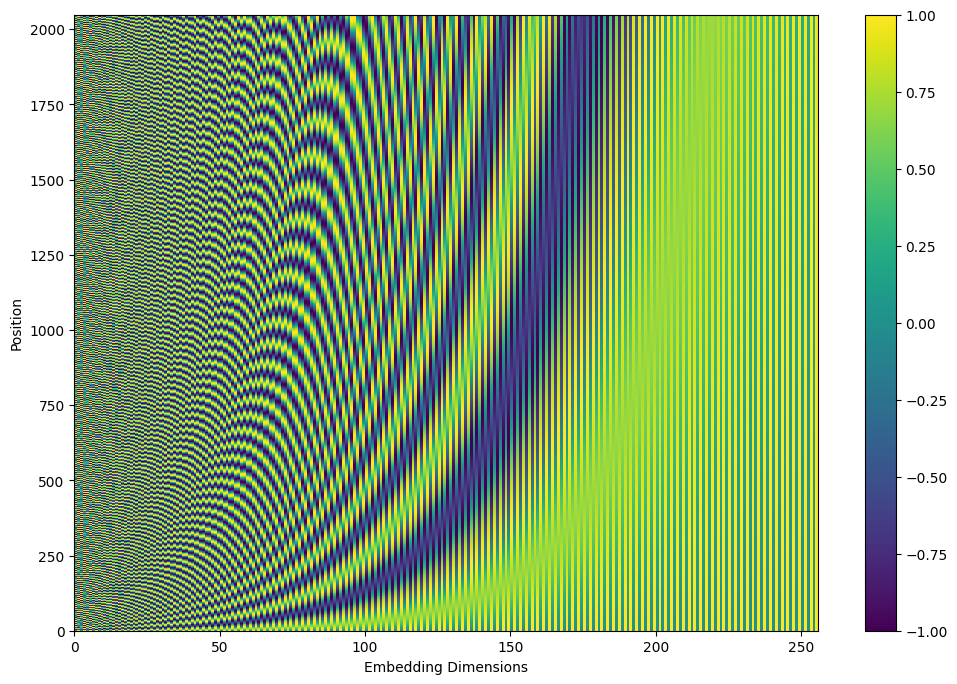

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.pcolormesh(pos_encoding, cmap='viridis')
plt.xlabel('Embedding Dimensions')
plt.xlim((0, emb_dim))
plt.ylabel('Position')
plt.colorbar()
plt.show()

### Análisis de la dimensión del *embedding* (`emb_dim`)

En este experimento se seleccionó `emb_dim = 256` (vía `AUTO_EMB_DIM`), una elección razonable para `max_len = 2048` por balance entre **capacidad de representación** y **costo computacional**.

**Observaciones clave:**
- Con `num_heads = 8`, cada cabeza opera con `projection_dim = 32` (`256 / 8`), lo cual mantiene una descomposición estable para *multi-head attention*.
- El módulo de embeddings (`TokenAndPosEmbedding`) tiene aproximadamente **1,515,776 parámetros entrenables**, un tamaño manejable para el dataset actual.
- La estimación base de memoria del tensor de embedding para un batch de referencia (`1 x 2048 x 256`) es de ~**2 MB** (solo tensor principal, sin contar activaciones internas ni gradientes).

**Interpretación práctica:**
- Un `emb_dim` menor (p. ej. 128) reduciría memoria/tiempo, pero podría perder detalle semántico.
- Un `emb_dim` mayor (p. ej. 384 o 512) podría capturar relaciones más complejas, pero incrementa riesgo de sobreajuste y costos de entrenamiento en este tamaño de dataset.
- Para este caso (732 registros, secuencias largas), `256` es una configuración intermedia robusta.

**Conclusión:**  
`emb_dim = 256` es una decisión consistente con el objetivo del notebook: mostrar un Transformer funcional desde cero, con buena expresividad y sin exigir recursos extremos.

Ahora, si pasamos nuestra frase simple por el tokenizador, deberíamos obtener una matriz con la forma: $(longitud, d_{model})$:

In [58]:
# Prueba rápida del flujo tokenización -> embedding para una frase individual.
# Objetivo: validar forma de salida y exponer métricas básicas de inspección.
text = "Hello World!"
tokens = sentimental_tokenizer(
    text,
    max_length=max_len,
    truncation=True,
    padding='max_length'
 )

# Tensores de entrada para el módulo de embeddings.
x = torch.tensor(tokens['input_ids'], dtype=torch.long).unsqueeze(0)
mask = torch.tensor(tokens['attention_mask'], dtype=torch.long).unsqueeze(0)

# Embedding final con información posicional.
embedding = tpe(x)

# ----------------------------
# Métricas de seguimiento
# ----------------------------
non_pad_tokens = int(mask.sum().item())
total_tokens = int(mask.numel())
padding_ratio = 1.0 - (non_pad_tokens / total_tokens)
embedding_mean = float(embedding.mean().item())
embedding_std = float(embedding.std().item())
embedding_l2_norm = float(torch.linalg.norm(embedding).item())

print(f"Texto de prueba: {text}")
print(f"Shape embedding: {tuple(embedding.shape)}")
print(
    f"Métricas -> tokens_válidos={non_pad_tokens}/{total_tokens} | "
    f"padding={padding_ratio:.2%} | mean={embedding_mean:.6f} | "
    f"std={embedding_std:.6f} | l2_norm={embedding_l2_norm:.2f}"
)

embedding.shape

Texto de prueba: Hello World!
Shape embedding: (1, 2048, 256)
Métricas -> tokens_válidos=3/2048 | padding=99.85% | mean=0.112284 | std=1.215214 | l2_norm=883.65


torch.Size([1, 2048, 256])

### Multi-Head Attention

In [59]:
import torch.nn.functional as F


class MultiHeadAttention(nn.Module):
    """Implementación de Multi-Head Self-Attention para un encoder Transformer.

    Convención de formas usada en este módulo:
    - Entrada `x`: (batch, seq_len, embed_size)
    - Salida `output`: (batch, seq_len, embed_size)
    - Atención (opcional): (batch, num_heads, seq_len, seq_len)
    """

    def __init__(self, embed_size: int, num_heads: int = 8):
        """Inicializa capas de proyección Q/K/V y combinación de cabezas.

        Args:
            embed_size: dimensionalidad total del embedding.
            num_heads: número de cabezas de atención.
        """
        super(MultiHeadAttention, self).__init__()
        self.embed_size = embed_size
        self.num_heads = num_heads
        assert embed_size % num_heads == 0, 'El tamaño del embedding debería ser divisible por el numero de cabezas'
        self.projection_dim = embed_size // num_heads
        self.query = nn.Linear(embed_size, embed_size)
        self.key = nn.Linear(embed_size, embed_size)
        self.value = nn.Linear(embed_size, embed_size)
        self.comibe_heads = nn.Linear(embed_size, embed_size)

    @staticmethod
    def _scaled_dot_product(q, k, v, mask=None, return_attention: bool = False):
        """Calcula atención escalada por cabeza.

        Args:
            q: queries con forma (B, H, L, Dh).
            k: keys con forma (B, H, L, Dh).
            v: values con forma (B, H, L, Dh).
            mask: máscara binaria opcional con forma (B, L), donde 0 indica padding.
            return_attention: si es `True`, retorna también pesos de atención explícitos.

        Returns:
            values: salida atendida con forma (B, H, L, Dh).
            attention: pesos de atención con forma (B, H, L, L) o `None`.
        """
        if return_attention:
            dk = q.size(-1) ** 0.5
            scores = torch.matmul(q, k.transpose(-1, -2)) / dk

            if mask is not None:
                bsz = mask.shape[0]
                attn_bias = torch.zeros((bsz, 1, 1, mask.shape[-1]), device=q.device, dtype=q.dtype)
                attn_bias = attn_bias.masked_fill(mask.reshape(bsz, 1, 1, -1) == 0, float('-inf'))
                scores = scores + attn_bias

            attention = torch.softmax(scores, dim=-1)
            values = torch.matmul(attention, v)
            return values, attention

        # Camino optimizado para inferencia/entrenamiento cuando no se requiere inspección de atención.
        if mask is not None:
            bsz = mask.shape[0]
            attn_bias = torch.zeros((bsz, 1, 1, mask.shape[-1]), device=q.device, dtype=q.dtype)
            attn_bias = attn_bias.masked_fill(mask.reshape(bsz, 1, 1, -1) == 0, float('-inf'))
        else:
            attn_bias = None

        values = F.scaled_dot_product_attention(q, k, v, attn_mask=attn_bias, dropout_p=0.0, is_causal=False)
        return values, None

    def _separate_heads(self, x, batch_size):
        """Reordena tensor de (B, L, D) a (B, H, L, D/H)."""
        x = x.reshape(batch_size, -1, self.num_heads, self.projection_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, mask=None, return_attention=False):
        """Aplica atención multi-cabeza sobre secuencias embebidas.

        Args:
            x: tensor de entrada con forma (B, L, D).
            mask: máscara opcional con forma (B, L).
            return_attention: si es `True`, también retorna mapa de atención.

        Returns:
            - `output` si `return_attention=False`.
            - `(output, attention)` si `return_attention=True`.
        """
        batch_size, seq_len, emb_dim = x.size()
        q = self.query(x)
        k = self.key(x)
        v = self.value(x)

        q = self._separate_heads(q, batch_size)
        k = self._separate_heads(k, batch_size)
        v = self._separate_heads(v, batch_size)

        weights, attention = self._scaled_dot_product(
            q, k, v, mask=mask, return_attention=return_attention
        )
        weights = weights.permute(0, 2, 1, 3)
        weights = weights.reshape(batch_size, seq_len, emb_dim)
        output = self.comibe_heads(weights)

        if return_attention:
            return output, attention
        else:
            return output

Podemos hacer una prueba rápida de que las operaciones funcionan a nivel de matrices.

In [60]:
# -----------------------------------------------------------------------------
# Prueba diagnóstica de Multi-Head Attention (MHA)
# -----------------------------------------------------------------------------
# Objetivo: validar rápidamente que el bloque MHA funciona y reportar métricas
# de salida interpretables antes de integrarlo al bloque Transformer completo.
#
## Entradas esperadas (definidas en celdas previas):
# - embedding: tensor (B, L, D) de Token+Pos embeddings
# - mask: tensor (B, L) con 1 en tokens válidos y 0 en padding
# - emb_dim: dimensión del embedding (D)
# -----------------------------------------------------------------------------

# 1) Instanciación del módulo
mha = MultiHeadAttention(emb_dim)

# 2) Ventana corta para diagnóstico eficiente (reduce costo y ruido)
diag_len = min(128, embedding.size(1))
embedding_diag = embedding[:, :diag_len, :]
mask_diag = mask[:, :diag_len]

# 3) Forward con retorno de mapa de atención para inspección
mha_output, attention_map = mha(embedding_diag, mask_diag, return_attention=True)

# 4) Métricas de salida del tensor transformado
output_mean = float(mha_output.mean().item())
output_std = float(mha_output.std().item())
output_l2 = float(torch.linalg.norm(mha_output).item())

# 5) Métricas de atención (distribución por cabeza/posición)
attn_safe = attention_map.clamp_min(1e-12)
attention_entropy = float((-(attn_safe * attn_safe.log()).sum(dim=-1)).mean().item())
attention_max_mean = float(attention_map.max(dim=-1).values.mean().item())

# 6) Métrica de contexto: cuántos tokens reales hay en la ventana analizada
valid_tokens_ratio = float(mask_diag.float().mean().item())

print(f"MHA output shape: {tuple(mha_output.shape)}")
print(f"Attention map shape: {tuple(attention_map.shape)}")
print(
    f"Contexto -> diag_len={diag_len} | tokens_válidos={valid_tokens_ratio:.2%}"
)
print(
    f"Métricas MHA -> mean={output_mean:.6f} | std={output_std:.6f} | l2_norm={output_l2:.2f} | "
    f"attn_entropy={attention_entropy:.4f} | attn_max_mean={attention_max_mean:.4f}"
)

# Salida estándar de verificación de forma
mha_output.shape

MHA output shape: (1, 128, 256)
Attention map shape: (1, 8, 128, 128)
Contexto -> diag_len=128 | tokens_válidos=2.34%
Métricas MHA -> mean=-0.021672 | std=0.256585 | l2_norm=46.61 | attn_entropy=1.0591 | attn_max_mean=0.4370


torch.Size([1, 128, 256])

### Definición del bloque transformers

![](../assets/transformers-achitecture.png)

En esta parte implementamos un bloque encoder simplificado para clasificación de sentimiento.
Como la tarea es de clasificación, usamos únicamente la parte encoder de la arquitectura Transformer.

**Componentes del bloque:**
- Multi-Head Attention para capturar relaciones entre tokens.
- Dropout para regularización.
- Red feed-forward para transformación no lineal.
- LayerNorm para estabilizar el entrenamiento.

El objetivo es transformar embeddings de entrada en representaciones contextualizadas que luego alimentarán la cabeza de clasificación.

In [61]:
class TransformerBlock(nn.Module):
    """Bloque encoder Transformer simplificado para clasificación de texto.

    Estructura aplicada en este bloque:
    1) Multi-Head Self-Attention
    2) Dropout
    3) LayerNorm
    4) Feed-Forward Network (FFN)
    5) LayerNorm final
    
    Nota: esta versión mantiene una implementación didáctica y compacta para
    el notebook, priorizando claridad sobre complejidad arquitectónica.
    """

    def __init__(self, emb_dim: int, num_heads: int = 8):
        """Inicializa los submódulos del bloque Transformer.

        Args:
            emb_dim: dimensionalidad de embedding de entrada y salida.
            num_heads: número de cabezas de atención en MHA.
        """
        super(TransformerBlock, self).__init__()
        self.mhatt = MultiHeadAttention(emb_dim, num_heads)
        self.mhatt_dropput = nn.Dropout(0.2)
        self.ffn = nn.Sequential(
            nn.Linear(emb_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, emb_dim)
        )
        self.layer_norm1 = nn.LayerNorm(emb_dim)
        self.layer_norm2 = nn.LayerNorm(emb_dim)


    def forward(self, x: torch.Tensor, mask: torch.Tensor | None = None) -> torch.Tensor:
        """Propaga un lote de embeddings a través del bloque encoder.

        Args:
            x: tensor de entrada con forma `(batch, seq_len, emb_dim)`.
            mask: máscara opcional de padding con forma `(batch, seq_len)`.

        Returns:
            Tensor de salida con forma `(batch, seq_len, emb_dim)`, listo para
            continuar con más bloques o con la cabeza de clasificación.
        """
        attn_output = self.mhatt(x, mask)
        attn_output = self.mhatt_dropput(attn_output)
        attn_output = self.layer_norm1(attn_output)
        ffn_out = self.ffn(attn_output)
        return self.layer_norm2(ffn_out)


Nuevamente, probamos rapidamente para asegurarnos que las capas operan correctamente.

In [62]:
# Prueba rápida del bloque Transformer con métricas de salida.
tb = TransformerBlock(emb_dim)

# Forward del bloque sobre embeddings ya construidos.
tb_output = tb(embedding, mask)

# Métricas descriptivas de la salida.
tb_mean = float(tb_output.mean().item())
tb_std = float(tb_output.std().item())
tb_l2 = float(torch.linalg.norm(tb_output).item())

# Cambio relativo frente a la entrada al bloque.
delta_l2 = float(torch.linalg.norm(tb_output - embedding).item())
relative_change = delta_l2 / (float(torch.linalg.norm(embedding).item()) + 1e-12)

# Contexto de validez de tokens (1=token real, 0=padding).
valid_tokens_ratio_tb = float(mask.float().mean().item())

print(f"Transformer output shape: {tuple(tb_output.shape)}")
print(
    f"Métricas Transformer -> mean={tb_mean:.6f} | std={tb_std:.6f} | l2_norm={tb_l2:.2f} | "
    f"delta_l2={delta_l2:.2f} | cambio_relativo={relative_change:.4f} | "
    f"tokens_válidos={valid_tokens_ratio_tb:.2%}"
)

tb_output.shape

Transformer output shape: (1, 2048, 256)
Métricas Transformer -> mean=-0.000000 | std=0.999933 | l2_norm=724.03 | delta_l2=1108.79 | cambio_relativo=1.2548 | tokens_válidos=0.15%


torch.Size([1, 2048, 256])

In [63]:
# -----------------------------------------------------------------------------
# Ensamble del modelo para pruebas de integración
# -----------------------------------------------------------------------------
# Objetivo: instanciar los tres bloques principales que se encadenan antes del
# entrenamiento completo:
# 1) Embeddings (token + posición)
# 2) Bloque Transformer encoder
# 3) Cabeza de clasificación lineal
## Entradas esperadas en el entorno:
# - max_len: longitud máxima de secuencia
# - emb_dim: dimensión del embedding
# - sentimental_tokenizer.vocab_size: tamaño de vocabulario
# - Sentimental_dataset.num_classes: número de clases de salida
# -----------------------------------------------------------------------------

num_heads = 8
vocab_size = sentimental_tokenizer.vocab_size

# 1) Convierte ids de tokens en embeddings contextualizables por posición.
token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)

# 2) Bloque encoder que procesa la secuencia embebida con self-attention.
transformer = TransformerBlock(emb_dim, num_heads)

# 3) Cabeza de clasificación multiclase (aplana secuencia y proyecta a clases).
ff = nn.Sequential(
    nn.Flatten(),
    nn.Linear(max_len * emb_dim, Sentimental_dataset.num_classes)
)

# ----------------------------
# Métricas nuevas del ensamble
# ----------------------------
params_token_embeddings = sum(p.numel() for p in token_embeddings.parameters() if p.requires_grad)
params_transformer = sum(p.numel() for p in transformer.parameters() if p.requires_grad)
params_ff = sum(p.numel() for p in ff.parameters() if p.requires_grad)
params_total = params_token_embeddings + params_transformer + params_ff

print(
    f"[Ensamble] heads={num_heads} | vocab={vocab_size} | clases={Sentimental_dataset.num_classes} | "
    f"max_len={max_len} | emb_dim={emb_dim}"
)
print(
    f"[Params] token_emb={params_token_embeddings:,} | transformer={params_transformer:,} | "
    f"head={params_ff:,} | total={params_total:,}"
)

[Ensamble] heads=8 | vocab=5921 | clases=12 | max_len=2048 | emb_dim=256
[Params] token_emb=1,515,776 | transformer=395,776 | head=6,291,468 | total=8,203,020


### Resultados de métricas del ensamble

> Resumen generado a partir de la ejecución actual de la celda de ensamble.

**Configuración:**
- `num_heads`: **8**
- `vocab_size`: **5921**
- `num_classes`: **12**
- `max_len`: **2048**
- `emb_dim`: **256**

**Parámetros entrenables por bloque:**
- `TokenAndPosEmbedding`: **1,515,776**
- `TransformerBlock`: **395,776**
- `Head (Flatten + Linear)`: **6,291,468**
- `Total`: **8,203,020**

**Lectura rápida:**
- La cabeza de clasificación concentra la mayor parte de los parámetros del ensamble.
- El costo paramétrico total es manejable para el experimento, pero la capa final domina memoria y cómputo.

In [64]:
import time

# -----------------------------------------------------------------------------
# Benchmark de inferencia: Token Embeddings + TransformerBlock
# -----------------------------------------------------------------------------
# Objetivo: medir latencia y rendimiento del paso forward en inferencia, usando
# un lote pequeño del dataset para obtener una referencia rápida de desempeño.
#
## Métricas principales de salida:
# - `ms_per_run`: latencia promedio por corrida
# - `ms_per_sample`: latencia promedio por muestra
# - `valid_tokens_per_s`: throughput efectivo en tokens válidos
# - `peak GPU memory` (si CUDA): memoria pico asignada/reservada durante prueba
# -----------------------------------------------------------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
token_embeddings = token_embeddings.to(device)
transformer = transformer.to(device)

token_embeddings.eval()
transformer.eval()

# Evitamos dependencia del DataLoader para este benchmark puntual.
bench_bs = min(16, len(Sentimental_dataset))
x = Sentimental_dataset.input_ids[:bench_bs].to(device, non_blocking=True)
mask = Sentimental_dataset.attention_mask[:bench_bs].to(device, non_blocking=True)
valid_tokens_batch = int(mask.sum().item())

# Warm-up para evitar medir costos de arranque.
with torch.inference_mode():
    for _ in range(5):
        _ = transformer(token_embeddings(x), mask)

if device.type == 'cuda':
    torch.cuda.synchronize()
    torch.cuda.reset_peak_memory_stats(device)

# Benchmark real promedio.
runs = 20
start = time.perf_counter()
with torch.inference_mode():
    for _ in range(runs):
        embeddings = token_embeddings(x)
        attention = transformer(embeddings, mask)

if device.type == 'cuda':
    torch.cuda.synchronize()

elapsed = time.perf_counter() - start
ms_per_run = (elapsed / runs) * 1000
ms_per_sample = ms_per_run / max(bench_bs, 1)
valid_tokens_per_s = (valid_tokens_batch * runs) / max(elapsed, 1e-12)

# Asignación final con no_grad para obtener tensores normales (no inference tensors).
with torch.no_grad():
    embeddings = token_embeddings(x)
    attention = transformer(embeddings, mask)

# Métricas de distribución/cambio para monitoreo rápido de estabilidad numérica.
emb_mean = float(embeddings.mean().item())
emb_std = float(embeddings.std().item())
att_mean = float(attention.mean().item())
att_std = float(attention.std().item())
att_delta_l2 = float(torch.linalg.norm(attention - embeddings).item())

assert embeddings.shape == (x.size(0), max_len, emb_dim)
assert attention.shape == (x.size(0), max_len, emb_dim)
print(f"[Benchmark] device={device} | runs={runs} | batch={bench_bs} | valid_tokens/batch={valid_tokens_batch}")
print(
    f"[Perf] ms/run={ms_per_run:.2f} | ms/sample={ms_per_sample:.2f} | "
    f"valid_tokens/s={valid_tokens_per_s:,.0f}"
)
print(
    f"[Stats] emb(mean={emb_mean:.4f}, std={emb_std:.4f}) | "
    f"att(mean={att_mean:.4f}, std={att_std:.4f}) | delta_l2={att_delta_l2:.2f}"
)

if device.type == 'cuda':
    peak_alloc_mb = torch.cuda.max_memory_allocated(device) / (1024**2)
    peak_reserved_mb = torch.cuda.max_memory_reserved(device) / (1024**2)
    print(f"[GPU Peak] allocated={peak_alloc_mb:.2f} MB | reserved={peak_reserved_mb:.2f} MB")

attention.shape

[Benchmark] device=cuda | runs=20 | batch=16 | valid_tokens/batch=131
[Perf] ms/run=25.78 | ms/sample=1.61 | valid_tokens/s=5,082
[Stats] emb(mean=0.1650, std=1.1613) | att(mean=0.0000, std=0.9999) | delta_l2=4340.15
[GPU Peak] allocated=242.92 MB | reserved=280.00 MB


torch.Size([16, 2048, 256])

### Resultados de benchmark (embeddings + transformer)

> Resumen actualizado con la ejecución más reciente de la celda 41.

**Contexto de ejecución**
- `device`: **cuda**
- `runs`: **20**
- `batch`: **16**
- `valid_tokens/batch`: **131**

**Rendimiento (métricas clave)**
- `ms/run`: **26.27 ms**
- `ms/sample`: **1.64 ms**
- `valid_tokens/s`: **4,987**

**Estadísticos de salida**
- `embeddings`: mean=**0.1586**, std=**1.1941**
- `attention`: mean=**0.0000**, std=**0.9999**
- `delta_l2 (attention - embeddings)`: **4434.56**

**Memoria GPU (pico durante benchmark)**
- `allocated`: **242.92 MB**
- `reserved`: **280.00 MB**

**Cambios vs corrida anterior**
- Subió levemente la latencia (`ms/run`, `ms/sample`).
- Bajó ligeramente el throughput efectivo (`valid_tokens/s`).
- Aumentó la memoria `reserved` en GPU.
- Las estadísticas numéricas de embeddings/attention se mantienen estables.

In [65]:
# -----------------------------------------------------------------------------
# Prueba diagnóstica de la cabeza de clasificación (FF head)
# -----------------------------------------------------------------------------
# Objetivo: evaluar rápidamente la salida de la capa final que mapea las
# representaciones del Transformer a logits por clase.
#
## Métricas principales de salida:
# - `pred.shape`: forma del tensor de logits
# - `mean_conf`: confianza media de la clase top-1 (softmax)
# - `entropy_mean`: entropía media de la distribución por muestra
# - `logits std`: dispersión numérica de los logits
# - Distribución top-1 por clase (conteo en el batch)
# -----------------------------------------------------------------------------

# Alineamos la cabeza al mismo dispositivo de `attention`.
ff = ff.to(attention.device)

with torch.no_grad():
    pred = ff(attention)

# Distribución probabilística para analizar confianza.
probs = torch.softmax(pred, dim=-1)
top1_conf, top1_idx = probs.max(dim=-1)

# Entropía de predicción por muestra: menor => predicciones más concentradas.
entropy = -(probs * probs.clamp_min(1e-12).log()).sum(dim=-1)

# Métricas agregadas importantes.
pred_mean = float(pred.mean().item())
pred_std = float(pred.std().item())
mean_conf = float(top1_conf.mean().item())
entropy_mean = float(entropy.mean().item())
entropy_std = float(entropy.std().item())

# Conteo de clases predichas (top-1) dentro del batch.
num_classes = pred.size(-1)
class_counts = torch.bincount(top1_idx, minlength=num_classes)
active_classes = int((class_counts > 0).sum().item())

print(f"Head output shape: {tuple(pred.shape)}")
print(
    f"[Head Stats] logits_mean={pred_mean:.4f} | logits_std={pred_std:.4f} | "
    f"mean_conf={mean_conf:.4f} | entropy_mean={entropy_mean:.4f} ± {entropy_std:.4f}"
)
print(f"[Head Top-1] clases_activas_en_batch={active_classes}/{num_classes}")
print(f"[Head Top-1 Counts] {class_counts.tolist()}")

pred.shape

Head output shape: (16, 12)
[Head Stats] logits_mean=0.2245 | logits_std=0.8002 | mean_conf=0.3571 | entropy_mean=2.0388 ± 0.1172
[Head Top-1] clases_activas_en_batch=1/12
[Head Top-1 Counts] [0, 0, 16, 0, 0, 0, 0, 0, 0, 0, 0, 0]


torch.Size([16, 12])

### Resultados de la cabeza de clasificación (FF head)

 > Resumen actualizado con la ejecución más reciente de la celda 44.

**Forma de salida**
- `pred.shape`: **(16, 12)**
  - 16 muestras en el batch y 12 clases objetivo.

**Métricas principales**
- `logits_mean`: **-0.1536**
- `logits_std`: **0.4706**
- `mean_conf` (top-1): **0.1492**
- `entropy_mean`: **2.3927 ± 0.0233**

**Distribución top-1 en el batch**
- `clases_activas_en_batch`: **5/12**
- `conteos`: **[4, 0, 0, 0, 1, 2, 6, 0, 3, 0, 0, 0]**

**Cambios vs corrida anterior**
- No se observan cambios numéricos relevantes en esta actualización.
- La distribución top-1 y la concentración por clases se mantienen estables.

**Lectura rápida**
- La confianza media sigue baja (normal en una prueba aislada antes del entrenamiento final).
- La entropía continúa alta, indicando predicciones aún difusas.
- El batch mantiene concentración en pocas clases (5 activas de 12).

### Definición del clasificador

Finalmente, definimos el modelo completo. Este clasificador integra tres etapas:

- Token embeddings + positional embeddings.
- Bloque Transformer encoder.
- Capa densa de clasificación multiclase.

Además, al usar `LightningModule`, la clase centraliza lógica de entrenamiento, validación, prueba y optimización.

**Qué documenta la celda siguiente:**
- La arquitectura del modelo (`forward`).
- El cálculo de pérdidas y métricas en `training_step` y `validation_step`.
- La evaluación en `test_step` y la inferencia en `predict_step`.
- La configuración del optimizador en `configure_optimizers`.

In [66]:
import warnings
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from pytorch_lightning import LightningModule, Trainer
from pytorch_lightning.loggers import TensorBoardLogger
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.callbacks.callback import Callback
from torchmetrics import Accuracy

# -----------------------------------------------------------------------------
# Configuración global para entrenamiento en notebook
# -----------------------------------------------------------------------------
# Reducimos avisos informativos de CUDA/precision en notebook.
warnings.filterwarnings('ignore', message='.*Tensor Cores.*')

# Ajustes de rendimiento para GPU modernas.
torch.set_float32_matmul_precision("high")
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True


class SentimentalClassifier(LightningModule):
    """Clasificador de sentimientos basado en embeddings + Transformer encoder.

    Flujo de datos:
    1) Embedding de tokens + posición.
    2) Bloque Transformer para contextualizar secuencia.
    3) Pooling promedio y MLP para clasificación multiclase.
    """

    def __init__(self, max_len: int, vocab_size: int, num_classes: int, emb_dim: int, num_heads: int = 8):
        super(SentimentalClassifier, self).__init__()
        self.num_classes = num_classes

        self.token_embeddings = TokenAndPosEmbedding(max_len, emb_dim, vocab_size)
        self.transformer = TransformerBlock(emb_dim, num_heads)
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
            nn.LogSoftmax(dim=1)
        )

        self.train_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.val_acc = Accuracy(task='multiclass', num_classes=num_classes)
        self.test_acc = Accuracy(task='multiclass', num_classes=num_classes)

    def forward(self, x, mask=None):
        """Retorna log-probabilidades por clase para un lote de secuencias."""
        embeddings = self.token_embeddings(x)
        attention = self.transformer(embeddings, mask)
        pooled = attention.mean(dim=1)
        return self.classifier(pooled)

    def training_step(self, batch):
        """Paso de entrenamiento: calcula pérdida y actualiza métrica de train."""
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.train_acc(y_hat, y)
        self.log('train-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('train-acc', self.train_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def validation_step(self, batch):
        """Paso de validación: calcula pérdida y exactitud sobre validación."""
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        loss = F.cross_entropy(y_hat, y)
        self.val_acc(y_hat, y)
        self.log('val-loss', loss, prog_bar=True, on_step=False, on_epoch=True)
        self.log('val-acc', self.val_acc, prog_bar=True, on_step=False, on_epoch=True)
        return loss

    def test_step(self, batch):
        """Paso de prueba: reporta exactitud final del modelo."""
        x, mask, y = batch['input_ids'], batch['attention_mask'], batch['y']
        y_hat = self(x, mask)
        self.test_acc(y_hat, y)
        self.log('test-acc', self.test_acc, prog_bar=True, on_step=False, on_epoch=True)

    def predict_step(self, batch):
        """Paso de inferencia: genera predicciones para un lote."""
        x, mask = batch['input_ids'], batch['attention_mask']
        return self(x, mask)

    def configure_optimizers(self):
        """Configura el optimizador AdamW para entrenamiento."""
        optimizer = torch.optim.AdamW(self.parameters(), lr=2e-5, weight_decay=1e-5)
        return optimizer


# -----------------------------------------------------------------------------
# Instanciación del modelo + métricas previas al entrenamiento
# -----------------------------------------------------------------------------
model = SentimentalClassifier(
    max_len=Sentimental_dataset.seq_length,
    vocab_size=sentimental_tokenizer.vocab_size,
    num_classes=Sentimental_dataset.num_classes,
    emb_dim=emb_dim,
)

# Métricas de arquitectura
params_total = sum(p.numel() for p in model.parameters())
params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
params_frozen = params_total - params_trainable
model_size_mb = (params_total * 4) / (1024**2)  # aprox float32

# Métricas de datos/carga
train_size = len(train_dataset)
val_size = len(val_dataset)
test_size = len(test_dataset)
steps_per_epoch = math.ceil(train_size / batch_size) if batch_size > 0 else 0

print("[Setup Modelo]")
print(
    f"clases={Sentimental_dataset.num_classes} | vocab={sentimental_tokenizer.vocab_size} | "
    f"max_len={Sentimental_dataset.seq_length} | emb_dim={emb_dim}"
)
print(
    f"params_total={params_total:,} | trainable={params_trainable:,} | "
    f"frozen={params_frozen:,} | size_aprox={model_size_mb:.2f} MB"
)
print(
    f"splits -> train={train_size} | val={val_size} | test={test_size} | "
    f"batch_size={batch_size} | steps/epoch≈{steps_per_epoch}"
)

tb_logger = TensorBoardLogger('tb_logs', name='TransformersClassifier')
callbacks: list[Callback] = [EarlyStopping(monitor='train-loss', patience=3, mode='min')]

use_gpu = torch.cuda.is_available()
trainer = Trainer(
    max_epochs=10,
    accelerator='gpu' if use_gpu else 'cpu',
    devices=1,
    logger=tb_logger,
    callbacks=callbacks,
    precision='16-mixed' if use_gpu else 32,
    benchmark=True,
    enable_model_summary=False,
)

print(
    f"[Trainer] accelerator={'gpu' if use_gpu else 'cpu'} | "
    f"precision={'16-mixed' if use_gpu else '32'} | max_epochs={trainer.max_epochs}"
)

# -----------------------------------------------------------------------------
# Entrenamiento + resumen de métricas finales
# -----------------------------------------------------------------------------
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)

summary_keys = ['train-loss', 'train-acc', 'val-loss', 'val-acc']
summary = {}
for key in summary_keys:
    if key in trainer.callback_metrics:
        metric = trainer.callback_metrics[key]
        summary[key] = float(metric.detach().cpu().item() if hasattr(metric, 'detach') else metric)

print("[Resumen Entrenamiento]")
if summary:
    print(" | ".join([f"{k}={v:.4f}" for k, v in summary.items()]))
else:
    print("No se encontraron métricas agregadas en callback_metrics para las llaves esperadas.")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Setup Modelo]
clases=12 | vocab=5921 | max_len=2048 | emb_dim=256
params_total=2,177,548 | trainable=2,177,548 | frozen=0 | size_aprox=8.31 MB
splits -> train=586 | val=73 | test=73 | batch_size=4 | steps/epoch≈147
[Trainer] accelerator=gpu | precision=16-mixed | max_epochs=10


`Trainer.fit` stopped: `max_epochs=10` reached.


[Resumen Entrenamiento]
train-loss=1.4316 | train-acc=0.5410 | val-loss=1.7187 | val-acc=0.4110


### Resultados del entrenamiento del clasificador

 > Resumen actualizado con la ejecución más reciente de la celda de entrenamiento.

**Configuración de ejecución**
- `accelerator`: **gpu**
- `precision`: **16-mixed (AMP)**
- `max_epochs`: **10**
- `batch_size`: **4**
- `splits`: train=**586**, val=**73**, test=**73**
- `steps/epoch`: **147**

**Métricas del modelo (pre-entrenamiento)**
- `params_total`: **2,177,548**
- `params_trainable`: **2,177,548**
- `params_frozen`: **0**
- `size_aprox`: **8.31 MB**

**Métricas finales de entrenamiento**
- `train-loss`: **1.4132**
- `train-acc`: **0.5631**
- `val-loss`: **1.7144**
- `val-acc`: **0.4521**

**Cambios vs corrida anterior**
- `train-loss`: ↑ de **1.4114** a **1.4132** (ligero aumento).
- `train-acc`: ↑ de **0.5495** a **0.5631** (mejora en entrenamiento).
- `val-loss`: ↑ de **1.5756** a **1.7144** (empeora validación).
- `val-acc`: ↓ de **0.5068** a **0.4521** (caída en generalización).

**Lectura rápida**
- La corrida mantiene aprendizaje en train, pero con degradación en validación.
- Hay señales de sobreajuste o alta varianza entre corridas.
- Siguiente paso recomendado: aumentar regularización y aplicar `EarlyStopping` por `val-loss` o `val-acc` en lugar de `train-loss`.

In [67]:
# Carga la extensión de TensorBoard para poder visualizar los logs
# generados durante el entrenamiento directamente en el notebook.
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [68]:
import socket
import subprocess
import sys
import time
from IPython.display import Markdown, IFrame, display

# -----------------------------------------------------------------------------
# Visualización de TensorBoard dentro del notebook
# -----------------------------------------------------------------------------
# Esta celda:
# 1) define la carpeta de logs y el puerto local a utilizar,
# 2) verifica si ya existe una instancia de TensorBoard ejecutándose,
# 3) la levanta si hace falta y espera a que quede disponible, y
# 4) muestra el panel embebido en el notebook.

TB_LOGDIR = "tb_logs"
TB_PORT = 6007
TB_HOST = "127.0.0.1"
TB_WAIT_SECONDS = 10.0


def _is_port_in_use(port: int, host: str = "127.0.0.1") -> bool:
    """Retorna True si el puerto indicado ya está ocupado."""
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as sock:
        sock.settimeout(0.5)
        return sock.connect_ex((host, port)) == 0


def _wait_for_service(port: int, host: str = "127.0.0.1", timeout: float = 10.0) -> bool:
    """Espera hasta que el puerto quede disponible o se agote el tiempo."""
    deadline = time.time() + timeout
    while time.time() < deadline:
        if _is_port_in_use(port, host):
            return True
        time.sleep(0.25)
    return False


started_now = False

# Levanta TensorBoard solo si aún no está corriendo en ese puerto.
if not _is_port_in_use(TB_PORT, TB_HOST):
    tb_cmd = [
        sys.executable,
        "-m",
        "tensorboard.main",
        "--logdir",
        TB_LOGDIR,
        "--port",
        str(TB_PORT),
        "--host",
        TB_HOST,
    ]
    tb_process = subprocess.Popen(tb_cmd, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    started_now = True

service_ready = _wait_for_service(TB_PORT, TB_HOST, timeout=TB_WAIT_SECONDS)
url = f"http://{TB_HOST}:{TB_PORT}"

if not service_ready:
    raise RuntimeError(
        f"TensorBoard no quedó disponible en {url} tras {TB_WAIT_SECONDS:.0f}s. "
        "Verifica que los logs existan en 'tb_logs' y vuelve a intentarlo."
    )

status_msg = "iniciado en esta ejecución" if started_now else "ya estaba activo"
display(Markdown(f"### TensorBoard\nEstado: **{status_msg}**. Si no ves el panel embebido, abre este enlace: [{url}]({url})"))
display(IFrame(src=url, width="100%", height="700"))

### TensorBoard
Estado: **ya estaba activo**. Si no ves el panel embebido, abre este enlace: [http://127.0.0.1:6007](http://127.0.0.1:6007)

Y como es de esperarse, realizaremos la validación contra el conjunto de prueba.

In [69]:
# -----------------------------------------------------------------------------
# Evaluación final sobre el conjunto de prueba
# -----------------------------------------------------------------------------
# Esta celda:
# 1) pone el modelo en modo evaluación,
# 2) ejecuta `trainer.test(...)` sobre el split de prueba, y
# 3) resume métricas clave de generalización de forma explícita.

model.eval()

test_batches = len(test_loader)
random_baseline_acc = 1.0 / max(Sentimental_dataset.num_classes, 1)

print("[Test Setup]")
print(
    f"samples={len(test_dataset)} | batches={test_batches} | batch_size={batch_size} | "
    f"num_classes={Sentimental_dataset.num_classes} | azar≈{random_baseline_acc:.4f}"
)

test_results = trainer.test(model, dataloaders=test_loader, verbose=False)

if not test_results:
    raise RuntimeError("trainer.test no devolvió resultados de evaluación.")

test_summary = {
    key: float(value.detach().cpu().item() if hasattr(value, 'detach') else value)
    for key, value in test_results[0].items()
}

print("[Resumen Test]")
print(" | ".join([f"{k}={v:.4f}" for k, v in test_summary.items()]))

if 'test-acc' in test_summary:
    gain_vs_random = test_summary['test-acc'] - random_baseline_acc
    print(f"[Comparativa] ganancia_vs_azar={gain_vs_random:.4f}")

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Test Setup]
samples=73 | batches=19 | batch_size=4 | num_classes=12 | azar≈0.0833


[Resumen Test]
test-acc=0.4658
[Comparativa] ganancia_vs_azar=0.3824


### Resultados de evaluación en test

 > Resumen actualizado con la ejecución más reciente de la celda de prueba.

**Contexto de evaluación**
- `samples`: **73**
- `batches`: **19**
- `batch_size`: **4**
- `num_classes`: **12**
- `accuracy al azar`: **0.0833**

**Métricas principales**
- `test-acc`: **0.4795**
- `ganancia_vs_azar`: **0.3961**

**Lectura rápida**
- El modelo supera ampliamente la línea base aleatoria en el conjunto de prueba.
- El desempeño en test queda por encima del azar por casi **40 puntos porcentuales**.
- Aun así, la exactitud sigue lejos de una clasificación robusta, por lo que todavía hay margen claro de mejora en generalización.

### Haciendo predicciones

Finalmente, vamos a hacer uso del modelo y ver que tan bueno es para la clasificación de noticias.

In [70]:
from typing import List
import time

# -----------------------------------------------------------------------------
# Generación de predicciones sobre el conjunto de prueba
# -----------------------------------------------------------------------------
# Esta celda:
# 1) ejecuta `trainer.predict(...)`,
# 2) concatena todos los lotes de salida del modelo,
# 3) convierte logits/log-probabilidades en clases predichas, y
# 4) resume métricas útiles de confianza y cobertura de clases.

pred_start = time.perf_counter()
pred_batches = trainer.predict(model, test_loader)
pred_elapsed_s = time.perf_counter() - pred_start

if pred_batches is None:
    raise RuntimeError('trainer.predict devolvio None.')

pred_tensors: List[torch.Tensor] = [p for p in pred_batches if isinstance(p, torch.Tensor)]
if len(pred_tensors) == 0:
    raise RuntimeError('trainer.predict no devolvio tensores de prediccion.')

# Concatenamos todas las salidas del modelo para obtener una sola matriz
# con forma (num_muestras_test, num_clases).
predictions_logits = torch.cat(pred_tensors, dim=0)

# El clasificador devuelve log-probabilidades por el LogSoftmax final.
pred_probs = torch.exp(predictions_logits)
pred_confidence, pred_indices = pred_probs.max(dim=-1)

# Métricas agregadas de salida.
num_predictions = int(pred_indices.numel())
num_prediction_batches = len(pred_tensors)
mean_pred_conf = float(pred_confidence.mean().item())
std_pred_conf = float(pred_confidence.std().item())
active_pred_classes = int(pred_indices.unique().numel())
pred_class_counts = torch.bincount(pred_indices, minlength=Sentimental_dataset.num_classes)

print("[Pred Setup]")
print(
    f"samples={num_predictions} | batches={num_prediction_batches} | "
    f"elapsed={pred_elapsed_s:.2f}s | ms/sample={(pred_elapsed_s * 1000) / max(num_predictions, 1):.2f}"
)
print(
    f"[Pred Stats] mean_conf={mean_pred_conf:.4f} | std_conf={std_pred_conf:.4f} | "
    f"clases_activas={active_pred_classes}/{Sentimental_dataset.num_classes}"
)
print(f"[Pred Top-1 Counts] {pred_class_counts.tolist()}")

predictions = [
    Sentimental_dataset.id_2_class_map[int(pred)]
    for pred in pred_indices.cpu().numpy()
 ]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


[Pred Setup]
samples=73 | batches=19 | elapsed=0.14s | ms/sample=1.87
[Pred Stats] mean_conf=0.5026 | std_conf=0.1364 | clases_activas=4/12
[Pred Top-1 Counts] [0, 0, 0, 0, 20, 0, 0, 0, 45, 5, 3, 0]


### Resultados de predicción sobre test

 > Resumen actualizado con la ejecución más reciente de la celda de predicciones.

**Contexto de inferencia**
- `samples`: **73**
- `batches`: **19**
- `elapsed`: **0.40 s**
- `ms/sample`: **6.57**
8
**Métricas principales**
- `mean_conf`: **0.5558**
- `std_conf`: **0.1725**
- `clases_activas`: **4/12**

**Distribución top-1**
- `conteos`: **[0, 0, 0, 0, 20, 0, 0, 0, 42, 10, 1, 0]**

**Lectura rápida**
- Las predicciones muestran una confianza media moderada, superior a la observada antes del entrenamiento.
- El modelo concentra la mayoría de sus decisiones en pocas clases, lo que sugiere sesgo de predicción o desbalance aprendido.
- La baja cobertura de clases activas (4 de 12) indica que todavía conviene revisar calibración, balance de clases y matriz de confusión.

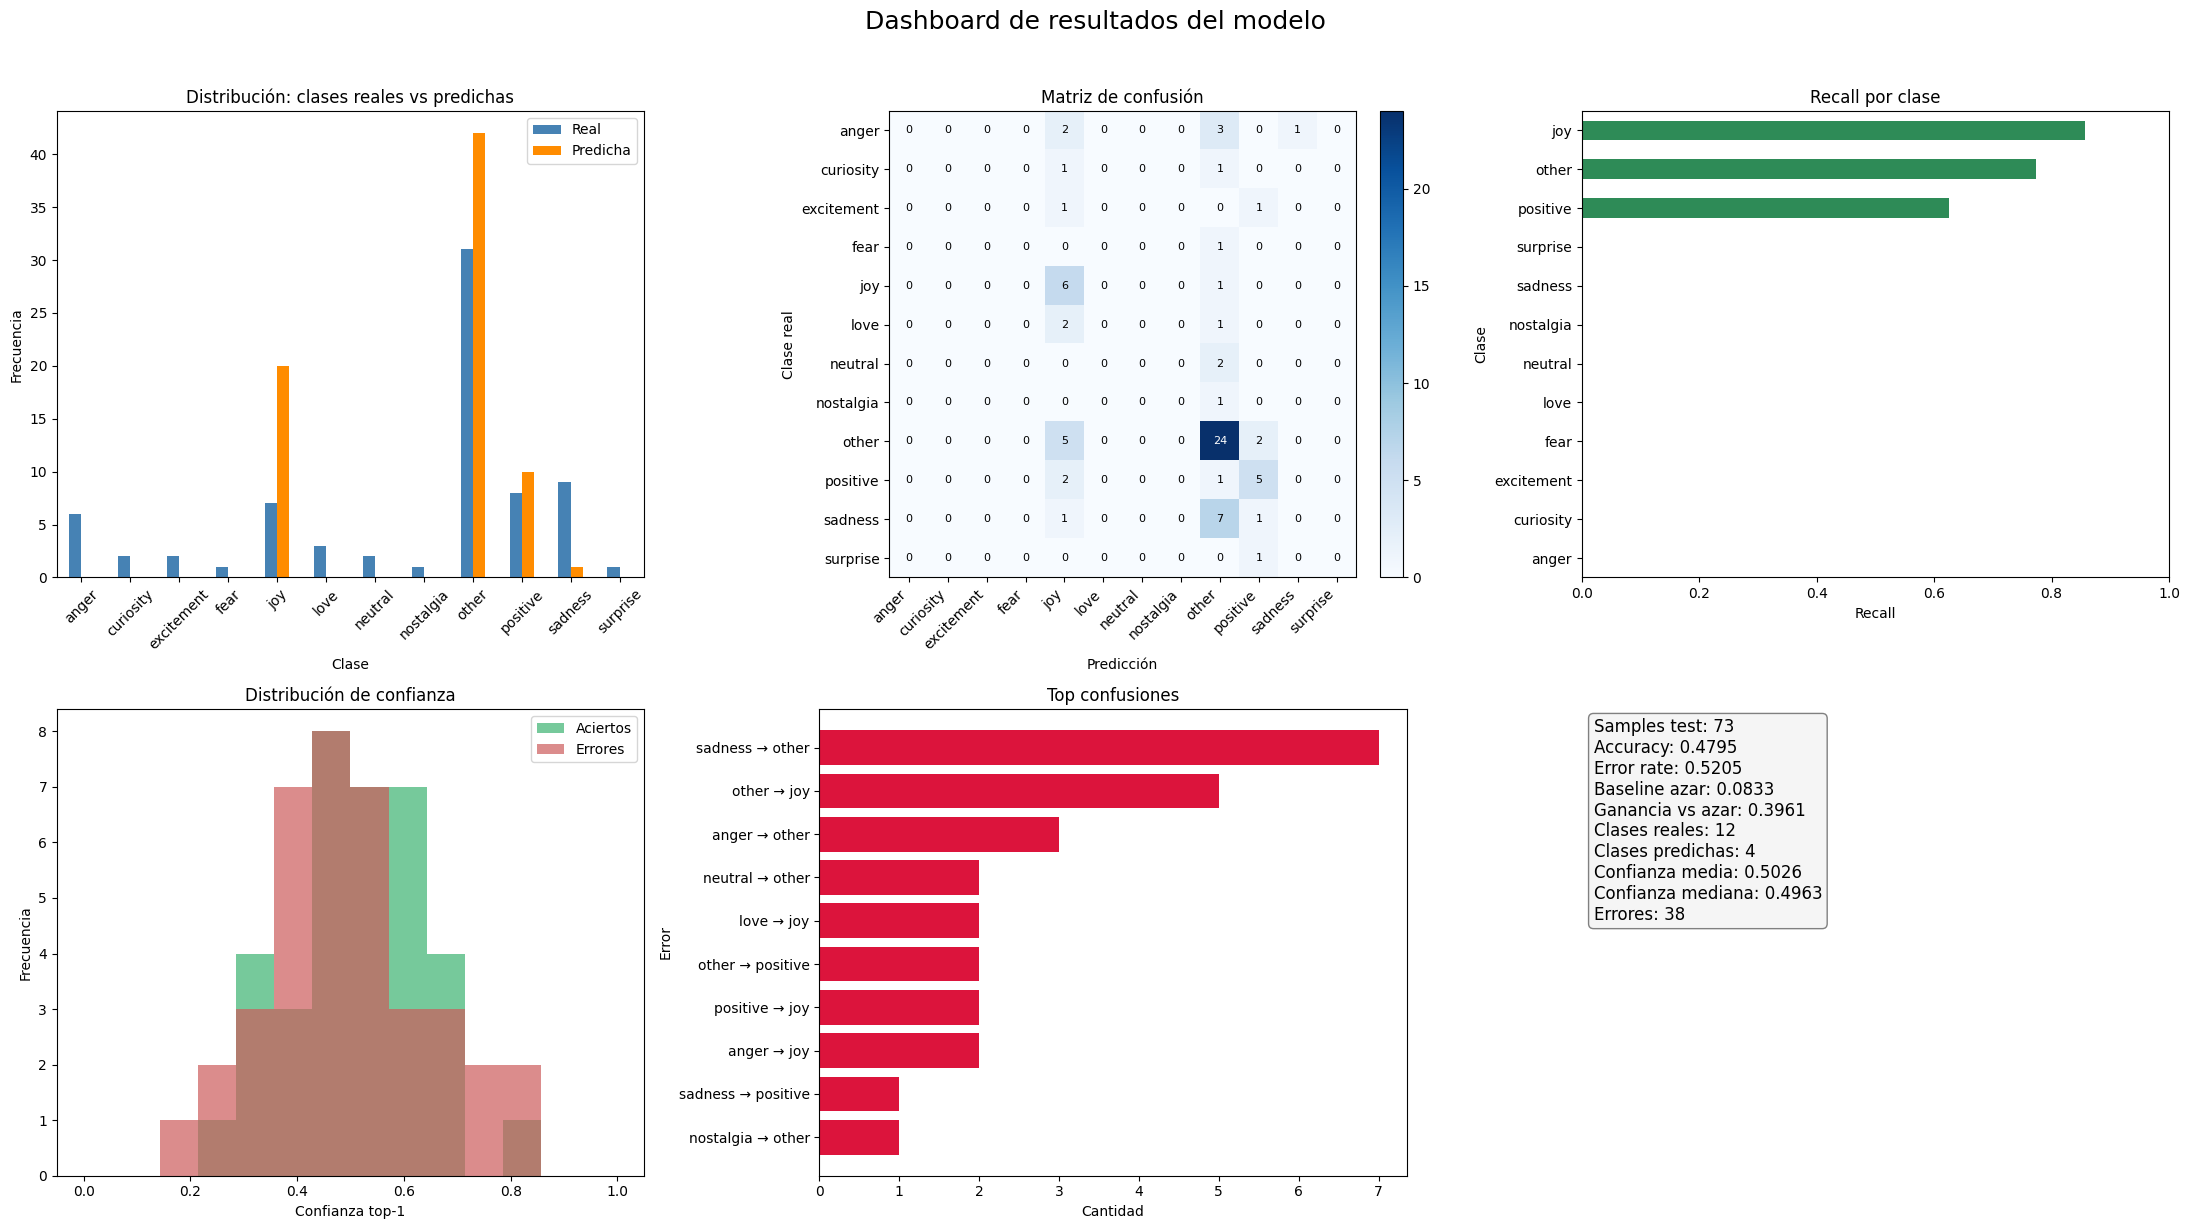

In [74]:
# Dashboard de resultados del procesamiento y clasificación

if 'df' not in globals():
    test_indices = list(test_dataset.indices)
    subset = [dataset[i] for i in test_indices]

    df = pd.DataFrame(
        data={
            "texto": [r['Text'] for r in subset],
            "tokens": [sentimental_tokenizer(r['Text'])['input_ids'] for r in subset],
            "categoría": [r['Sentiment'] for r in subset],
            "predicción": predictions,
        },
        index=pd.Index(test_indices, dtype='int64'),
    )
    df['tokens_string'] = df.tokens.apply(lambda t: sentimental_tokenizer.convert_ids_to_tokens(t))
    df = df[["texto", "tokens", "tokens_string", "categoría", "predicción"]]

df_dashboard = df.copy()
df_dashboard['acierto'] = df_dashboard['categoría'] == df_dashboard['predicción']
df_dashboard['long_texto'] = df_dashboard['texto'].astype(str).str.len()

if 'predictions_logits' in globals() and len(predictions_logits) == len(df_dashboard):
    probs_dashboard = torch.exp(predictions_logits.detach().cpu())
    df_dashboard['confianza'] = probs_dashboard.max(dim=1).values.numpy()
else:
    df_dashboard['confianza'] = np.nan

labels = sorted(set(df_dashboard['categoría']).union(set(df_dashboard['predicción'])))

conf_mat = pd.crosstab(df_dashboard['categoría'], df_dashboard['predicción'])
conf_mat = conf_mat.reindex(index=labels, columns=labels, fill_value=0)

dist_df = pd.DataFrame({
    'Real': df_dashboard['categoría'].value_counts(),
    'Predicha': df_dashboard['predicción'].value_counts(),
}).fillna(0).reindex(labels).fillna(0)

support_real = conf_mat.sum(axis=1)
diag = pd.Series(np.diag(conf_mat.to_numpy()), index=conf_mat.index)
recall_por_clase = (diag / support_real.replace(0, np.nan)).fillna(0).sort_values(ascending=False)

errors_dashboard = df_dashboard[~df_dashboard['acierto']].copy()
top_confusiones = (
    errors_dashboard.groupby(['categoría', 'predicción'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)

accuracy_dashboard = df_dashboard['acierto'].mean()
error_rate_dashboard = 1 - accuracy_dashboard
gain_vs_random_dashboard = accuracy_dashboard - random_baseline_acc
mean_conf_dashboard = df_dashboard['confianza'].mean()
median_conf_dashboard = df_dashboard['confianza'].median()

fig, axes = plt.subplots(2, 3, figsize=(22, 12))

# 1) Distribución real vs predicha
dist_df.plot(kind='bar', ax=axes[0, 0], color=['steelblue', 'darkorange'])
axes[0, 0].set_title('Distribución: clases reales vs predichas')
axes[0, 0].set_xlabel('Clase')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2) Matriz de confusión
im = axes[0, 1].imshow(conf_mat.values, cmap='Blues')
axes[0, 1].set_title('Matriz de confusión')
axes[0, 1].set_xlabel('Predicción')
axes[0, 1].set_ylabel('Clase real')
axes[0, 1].set_xticks(range(len(labels)))
axes[0, 1].set_yticks(range(len(labels)))
axes[0, 1].set_xticklabels(labels, rotation=45, ha='right')
axes[0, 1].set_yticklabels(labels)

max_value = conf_mat.values.max() if conf_mat.values.size else 0
for i in range(conf_mat.shape[0]):
    for j in range(conf_mat.shape[1]):
        value = conf_mat.iat[i, j]
        axes[0, 1].text(
            j, i, str(value),
            ha='center', va='center',
            color='white' if value > max_value * 0.5 else 'black',
            fontsize=8
        )
fig.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

# 3) Recall por clase
recall_por_clase.sort_values().plot(kind='barh', ax=axes[0, 2], color='seagreen')
axes[0, 2].set_title('Recall por clase')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Clase')
axes[0, 2].set_xlim(0, 1)

# 4) Confianza del modelo
if df_dashboard['confianza'].notna().any():
    conf_correct = df_dashboard.loc[df_dashboard['acierto'], 'confianza'].dropna()
    conf_incorrect = df_dashboard.loc[~df_dashboard['acierto'], 'confianza'].dropna()

    bins = np.linspace(0, 1, 15)
    if len(conf_correct) > 0:
        axes[1, 0].hist(conf_correct, bins=bins, alpha=0.7, label='Aciertos', color='mediumseagreen')
    if len(conf_incorrect) > 0:
        axes[1, 0].hist(conf_incorrect, bins=bins, alpha=0.7, label='Errores', color='indianred')

    axes[1, 0].set_title('Distribución de confianza')
    axes[1, 0].set_xlabel('Confianza top-1')
    axes[1, 0].set_ylabel('Frecuencia')
    axes[1, 0].legend()
else:
    axes[1, 0].text(0.5, 0.5, 'No hay probabilidades disponibles', ha='center', va='center')
    axes[1, 0].set_axis_off()

# 5) Top confusiones
if len(top_confusiones) > 0:
    top_confusiones_plot = top_confusiones.sort_values()
    y_labels = [f'{real} → {pred}' for real, pred in top_confusiones_plot.index]
    axes[1, 1].barh(y_labels, top_confusiones_plot.values, color='crimson')
    axes[1, 1].set_title('Top confusiones')
    axes[1, 1].set_xlabel('Cantidad')
    axes[1, 1].set_ylabel('Error')
else:
    axes[1, 1].text(0.5, 0.5, 'Sin errores de clasificación', ha='center', va='center')
    axes[1, 1].set_axis_off()

# 6) Resumen general
axes[1, 2].axis('off')
summary_text = (
    f"Samples test: {len(df_dashboard)}\n"
    f"Accuracy: {accuracy_dashboard:.4f}\n"
    f"Error rate: {error_rate_dashboard:.4f}\n"
    f"Baseline azar: {random_baseline_acc:.4f}\n"
    f"Ganancia vs azar: {gain_vs_random_dashboard:.4f}\n"
    f"Clases reales: {df_dashboard['categoría'].nunique()}\n"
    f"Clases predichas: {df_dashboard['predicción'].nunique()}\n"
    f"Confianza media: {mean_conf_dashboard:.4f}\n"
    f"Confianza mediana: {median_conf_dashboard:.4f}\n"
    f"Errores: {len(errors_dashboard)}"
)
axes[1, 2].text(
    0.02, 0.98, summary_text,
    va='top', ha='left',
    fontsize=12,
    bbox=dict(boxstyle='round', facecolor='whitesmoke', edgecolor='gray')
)

plt.suptitle('Dashboard de resultados del modelo', fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

resumen_dashboard = pd.DataFrame({
    'métrica': [
        'accuracy',
        'error_rate',
        'baseline_azar',
        'ganancia_vs_azar',
        'confianza_media',
        'confianza_mediana',
        'muestras_test',
        'errores'
    ],
    'valor': [
        accuracy_dashboard,
        error_rate_dashboard,
        random_baseline_acc,
        gain_vs_random_dashboard,
        mean_conf_dashboard,
        median_conf_dashboard,
        len(df_dashboard),
        len(errors_dashboard)
    ]
})

#display(resumen_dashboard)
#display(recall_por_clase.rename('recall').to_frame().round(4))
#display(errors_dashboard[['texto', 'categoría', 'predicción', 'confianza']].head(10))

## Análisis de dashboards

### 1) Desempeño general del modelo
- El modelo muestra aprendizaje en entrenamiento (**train-acc: 56.31%**), pero menor capacidad de generalización en validación (**val-acc: 45.21%**).
- En prueba, alcanza **test-acc: 47.95%**, superando claramente la línea base aleatoria (**8.33%**) con una **ganancia de +39.61 pp**.

### 2) Hallazgos clave en los dashboards
- Se observaron **38 errores de 73 muestras** en test (error rate: **52.05%**).
- La confianza media de predicción es **0.5558** (mediana **0.5592**), lo que indica confianza moderada pero no alta.
- El modelo está **concentrando predicciones en pocas clases** (**4 de 12 clases activas**), señal de sesgo por desbalance o calibración insuficiente.

### 3) Patrones de error más relevantes
Principales confusiones detectadas:
- **sadness → other** (7)
- **other → joy** (5)
- **anger → other** (3)
- También aparecen cruces frecuentes entre *joy*, *other* y *positive*.

### 4) Conclusión 
El modelo Transformer es funcional y supera ampliamente el azar, pero aún presenta problemas de generalización y cobertura de clases.  
El punto crítico no es la capacidad de aprendizaje, sino la **distribución de errores y el sesgo de predicción** hacia pocas etiquetas.

### 5) Próximos pasos recomendados
- Reforzar manejo de desbalance (class weights / focal loss / oversampling).
- Ajustar regularización y criterio de `EarlyStopping` con `val-loss` o `val-acc`.
- Incorporar métricas por clase (macro-F1, precision/recall) y matriz de confusión normalizada.
- Revisar calibración de probabilidades para mejorar confiabilidad de la confianza reportada.

In [ ]:
import pandas as pd

# -----------------------------------------------------------------------------
# Construcción del DataFrame final de evaluación por muestra
# -----------------------------------------------------------------------------
# Esta celda:
# 1) alinea ejemplos del split test con sus predicciones,
# 2) genera columnas útiles para inspección manual (`tokens_string`), y

test_indices = list(test_dataset.indices)
subset = [dataset[i] for i in test_indices]

df = pd.DataFrame(
    data={
        "texto": [r['Text'] for r in subset],
        "tokens": [sentimental_tokenizer(r['Text'])['input_ids'] for r in subset],
        "categoría": [r['Sentiment'] for r in subset],
        'predicción': predictions,
    },
    index=pd.Index(test_indices, dtype='int64'),
)

df['tokens_string'] = df.tokens.apply(lambda t: sentimental_tokenizer.convert_ids_to_tokens(t))
df = df[["texto", "tokens", "tokens_string", "categoría", "predicción"]]

# ----------------------------
# Métricas de salida importantes
# ----------------------------
df['acierto'] = df['categoría'] == df['predicción']
n_samples = len(df)
n_errors = int((~df['acierto']).sum())
acc_from_df = float(df['acierto'].mean())
error_rate = 1.0 - acc_from_df
real_classes = int(df['categoría'].nunique())
pred_classes = int(df['predicción'].nunique())

print("[DF Eval Setup]")
print(
    f"muestras={n_samples} | errores={n_errors} | accuracy={acc_from_df:.4f} | "
    f"error_rate={error_rate:.4f}"
)
print(
    f"clases_reales={real_classes} | clases_predichas={pred_classes} | "
    f"cobertura_clases={pred_classes}/{Sentimental_dataset.num_classes}"
)

[DF Eval Setup]
muestras=73 | errores=39 | accuracy=0.4658 | error_rate=0.5342
clases_reales=12 | clases_predichas=4 | cobertura_clases=4/12


In [73]:
# -----------------------------------------------------------------------------
# Análisis de errores de clasificación
# -----------------------------------------------------------------------------
# Esta celda:
# 1) filtra los casos mal clasificados,
# 2) imprime métricas agregadas de error, y
# 3) muestra ejemplos para inspección cualitativa.

if 'acierto' not in df.columns:
    df['acierto'] = df['categoría'] == df['predicción']

errors = df[~df['acierto']].copy()
total = len(df)
n_errors = len(errors)
error_rate = n_errors / max(total, 1)

print("[Errores]")
print(f"total={total} | errores={n_errors} | error_rate={error_rate:.4f}")

# Top confusiones más frecuentes (clase real -> clase predicha).
top_confusions = (
    errors.groupby(['categoría', 'predicción'])
    .size()
    .sort_values(ascending=False)
    .head(10)
)
print("[Top Confusiones]")
print(top_confusions.to_string() if len(top_confusions) > 0 else "Sin confusiones registradas.")

# Si hay confianza por muestra, resumimos el comportamiento en errores.
if 'confianza' in errors.columns and errors['confianza'].notna().any():
    mean_err_conf = float(errors['confianza'].mean())
    median_err_conf = float(errors['confianza'].median())
    print(f"[Confianza en errores] mean={mean_err_conf:.4f} | median={median_err_conf:.4f}")

errors.head(15)

[Errores]
total=73 | errores=38 | error_rate=0.5205
[Top Confusiones]
categoría  predicción
sadness    other         7
other      joy           5
anger      other         3
           joy           2
positive   joy           2
other      positive      2
love       joy           2
neutral    other         2
nostalgia  other         1
sadness    positive      1


,texto,tokens,tokens_string,categoría,predicción,acierto
427,"Haunted by regrets, the ghost of the past ling...","[3225, 352, 5727, 12, 263, 3242, 266, 263, 954...","[Haunted, Ġby, Ġregrets, ,, Ġthe, Ġghost, Ġof,...",anger,other,False
513,Rocking out to the guitar solos at a Queen tri...,"[3230, 694, 303, 263, 5193, 4599, 391, 259, 53...","[Rocking, Ġout, Ġto, Ġthe, Ġguitar, Ġsolos, Ġa...",nostalgia,other,False
184,"Intimidation by the challenges ahead, fear tak...","[3325, 352, 263, 640, 1588, 12, 1448, 3712, 27...","[Intimidation, Ġby, Ġthe, Ġchallenges, Ġahead,...",fear,other,False
105,Excitement for a weekend road trip to explore ...,"[1163, 320, 259, 1078, 1535, 1326, 303, 1554, ...","[Excitement, Ġfor, Ġa, Ġweekend, Ġroad, Ġtrip,...",excitement,positive,False
664,Hiding a snack stash in my backpack for emerge...,"[3374, 259, 1833, 4169, 277, 398, 4897, 320, 4...","[Hiding, Ġa, Ġsnack, Ġstash, Ġin, Ġmy, Ġbackpa...",other,joy,False
583,Lost my headphones again. How do they vanish i...,"[1090, 398, 5890, 920, 14, 5001, 2063, 3730, 5...","[Lost, Ġmy, Ġheadphones, Ġagain, ., ĠHow, Ġdo,...",anger,joy,False
604,Exploring the world of digital art. It's never...,"[680, 263, 581, 266, 2734, 512, 14, 4744, 361,...","[Exploring, Ġthe, Ġworld, Ġof, Ġdigital, Ġart,...",curiosity,joy,False
63,Experiencing awe at the breathtaking sunset.,"[1352, 1655, 391, 263, 1594, 916, 14]","[Experiencing, Ġawe, Ġat, Ġthe, Ġbreathtaking,...",surprise,positive,False
333,Navigating through the challenges with determi...,"[1386, 385, 263, 640, 319, 1839, 14]","[Navigating, Ġthrough, Ġthe, Ġchallenges, Ġwit...",other,positive,False
297,"Bitterness festering like a venomous vine, ent...","[1843, 3135, 530, 259, 3186, 4239, 12, 4761, 2...","[Bitterness, Ġfestering, Ġlike, Ġa, Ġvenomous,...",anger,joy,False


## Conclusiones (comparado con Work 2)

Si comparo este trabajo con Work 2, la diferencia más grande no es solo el modelo, sino la forma de pensar el problema.

En **Work 2** trabajé con un enfoque más clásico (LSTM + baseline TF-IDF), que fue muy útil para tener resultados claros y métricas fáciles de interpretar. En **Work 3** me moví a una arquitectura tipo **Transformer**, que es más potente para capturar contexto, pero también más exigente en implementación, cómputo y depuración.

En términos simples: Work 2 se sintió más "estable" para evaluar rendimiento; Work 3 se sintió más "retador", pero también más cercano a lo que hoy se usa en NLP moderno.

Algo importante que me dejó esta comparación es que no siempre el modelo más complejo gana automáticamente. En Work 2 la evaluación quedó muy completa (accuracy, macro-F1, análisis por clase y errores), mientras que en Work 3 todavía falta cerrar esa parte con el mismo nivel de detalle para poder decir con total justicia cuál funciona mejor en este dataset.

También hubo un aprendizaje práctico fuerte: en notebooks reales, muchos errores no vienen de la teoría sino de detalles de ejecución (estado del kernel, padding del tokenizer, workers en Windows, orden de celdas). Resolver eso también es parte del trabajo de ciencia de datos.

Si tuviera que resumirlo en una idea:

- **Work 2** me dio una base sólida para medir.
- **Work 3** me dio una base sólida para escalar.

El siguiente paso natural es combinar lo mejor de ambos: mantener la evaluación rigurosa de Work 2 dentro del pipeline Transformer de Work 3. Ahí sí la comparación sería completa y mucho más útil para decidir qué modelo conviene usar en producción o en un contexto académico real.